In [202]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os


In [203]:
data_path = Path(r"C:\Users\Daniel K\Desktop\DAKI\3. Semester\P3\inference_data")

In [ ]:
#hw_files = sorted(f for f in data_path.glob("*.csv") if not f.stem.endswith("_lat"))
# Get CSV files, ignore *_lat files, and filter by second-to-last character
hw_files = sorted(f for f in data_path.glob("*.csv") if not f.stem.endswith("_lat"))# and f.stem[-2] == "1")


hw_files


[WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/mobileNet128_312.csv'),
 WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/mobileNet256_513.csv'),
 WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/mobileNet64_111.csv'),
 WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/unet128_812.csv'),
 WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/unet128pconv_1112.csv'),
 WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/unet256_913.csv'),
 WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/unet256pconv_1213.csv'),
 WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/unet64_711.csv'),
 WindowsPath('C:/Users/Daniel K/Desktop/DAKI/3. Semester/P3/inference_data/unet64pconv_1011.csv')]

In [205]:
# Extract model names (everything before the first '_')
model_names = [f.stem.split("_")[0] for f in hw_files]

In [206]:
# Create a dictionary mapping model name → file
data = {}
for f in hw_files:
    model = f.stem.split("_")[0]  # name before first _
    df = pd.read_csv(f)
    # Convert absolute timestamp → relative time
    df["time_s"] = df["ts"] - df["ts"].iloc[0]
    df = df.set_index("time_s")
    data[model] = df




In [207]:
# Smoothing parameters
TIME_WINDOW = "10s"
variables = [
    "gpu", "cpu1", "cpu2", "cpu3", "cpu4",
    "ram", "temp_gpu", "temp_cpu", "power"
]


In [208]:
# Prepare colors for models
models = sorted(data.keys())
colors = plt.cm.tab20(range(len(models)))  # more distinct colors
color_map = dict(zip(models, colors))


In [209]:
# Compute smoothed variables
for model, df in data.items():
    for var in variables:
        if var in df.columns:
            df.index = pd.to_timedelta(df.index, unit='s')  # convert seconds to timedelta
            df[f"{var}_smooth"] = df[var].rolling(TIME_WINDOW).mean()
    data[model] = df


## Test

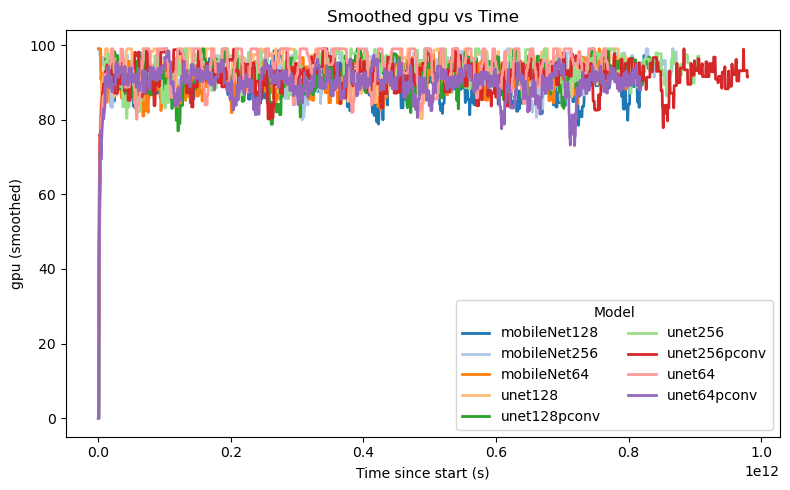

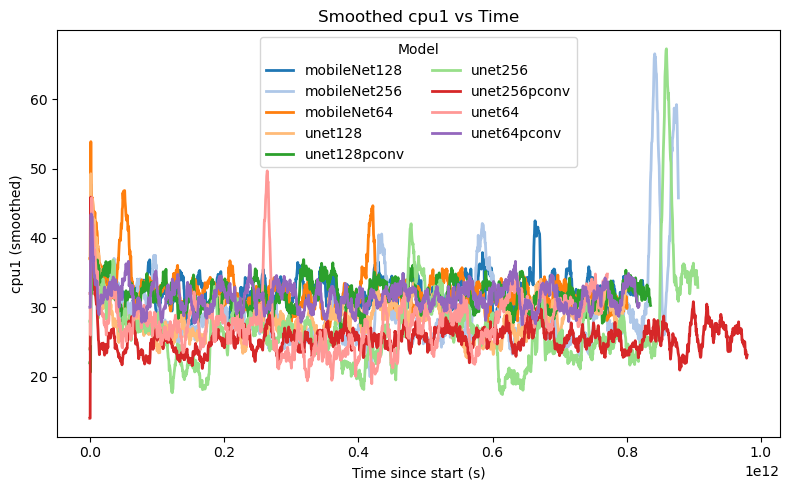

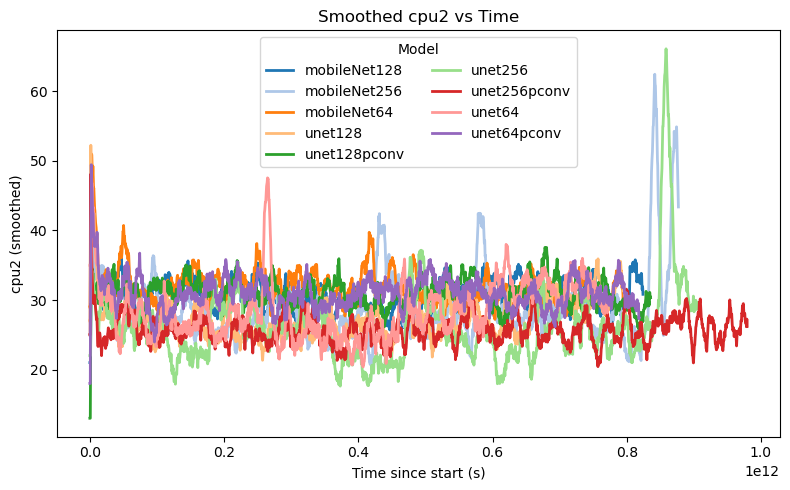

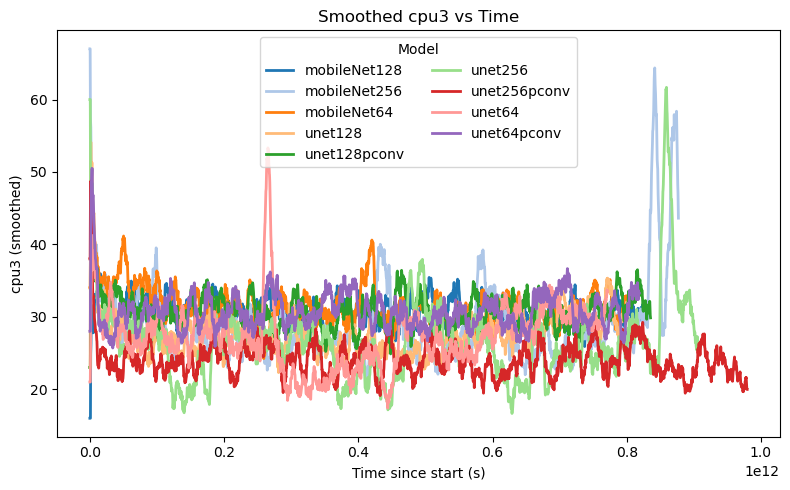

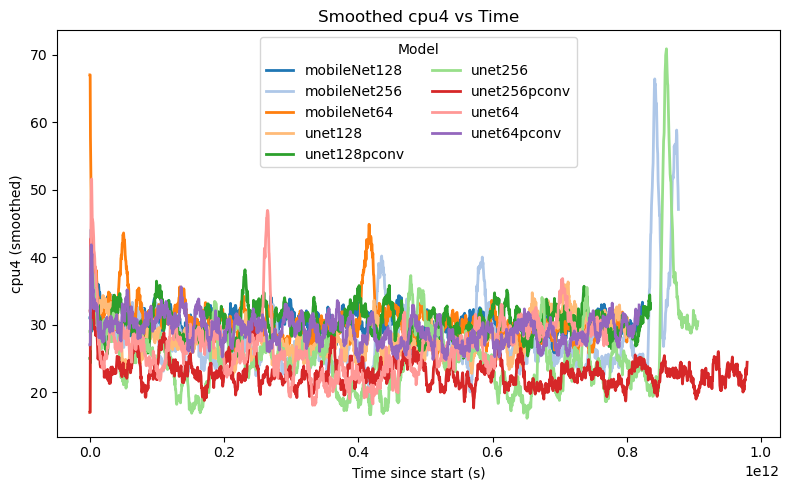

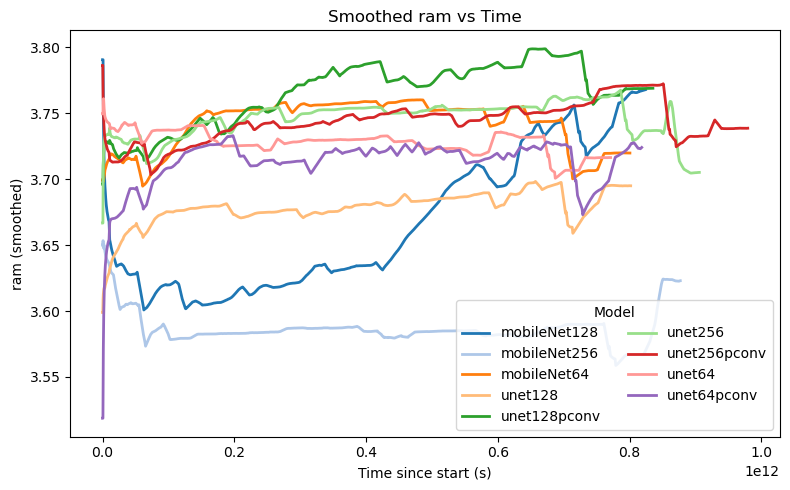

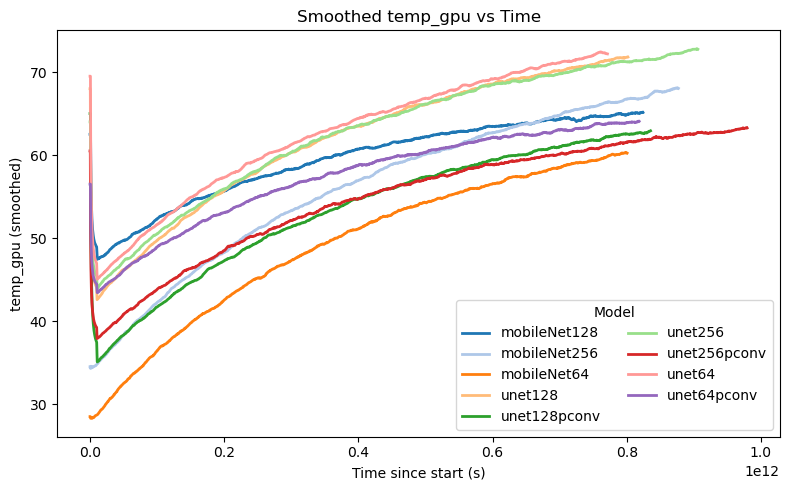

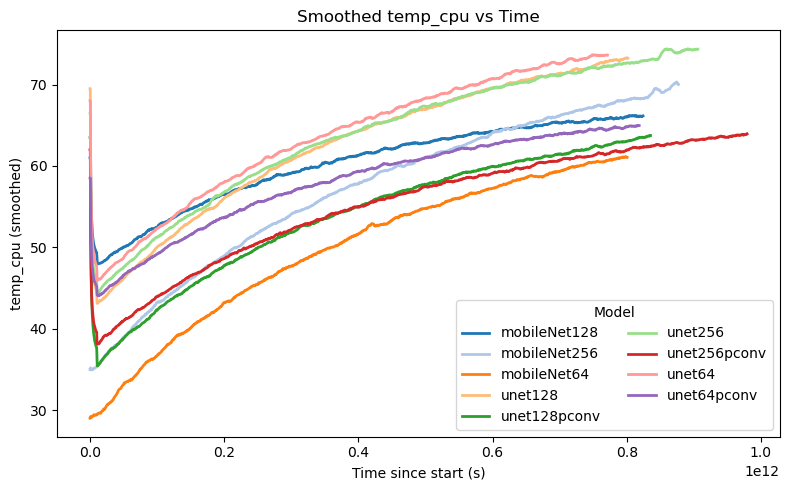

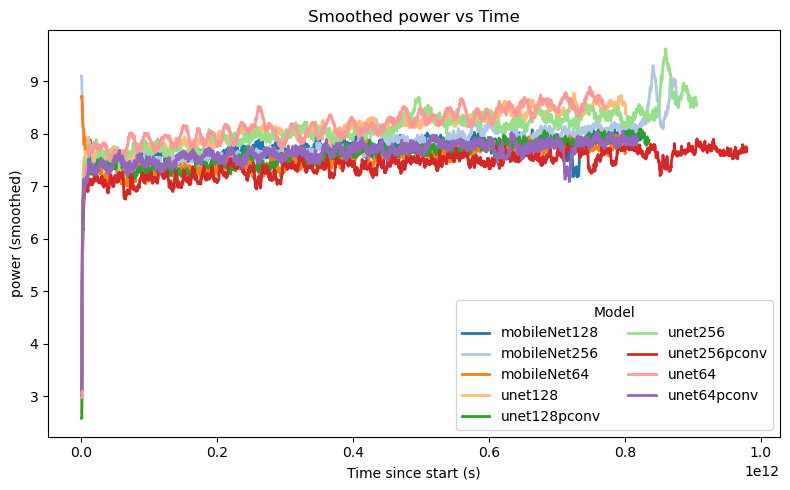

In [210]:
# Plot all variables
for var in variables:
    plt.figure(figsize=(8,5))
    for model, df in data.items():
        if f"{var}_smooth" in df.columns:
            plt.plot(df.index, df[f"{var}_smooth"], label=model, color=color_map[model], linewidth=2)
    plt.xlabel("Time since start (s)")
    plt.ylabel(f"{var} (smoothed)")
    plt.title(f"Smoothed {var} vs Time")
    plt.legend(title="Model", ncol=2)
    plt.tight_layout()
    plt.show()

# Data

## Everything

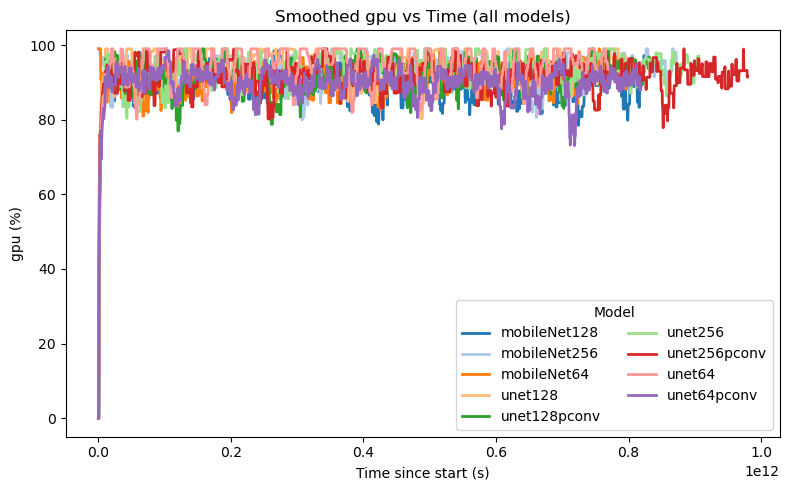

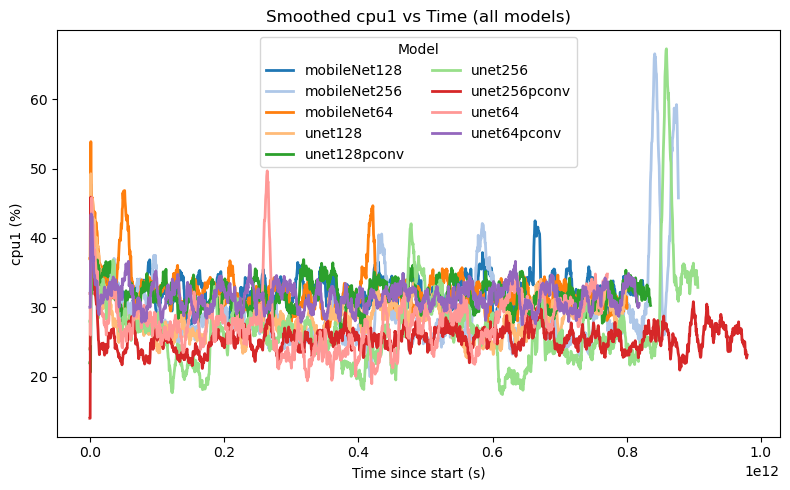

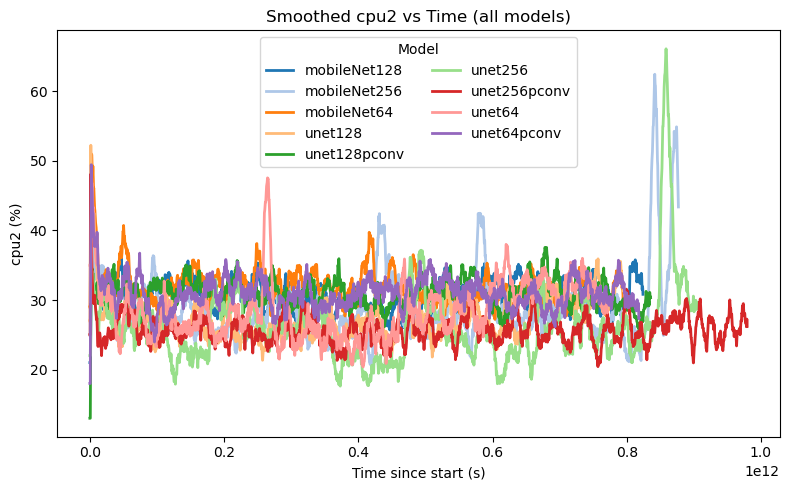

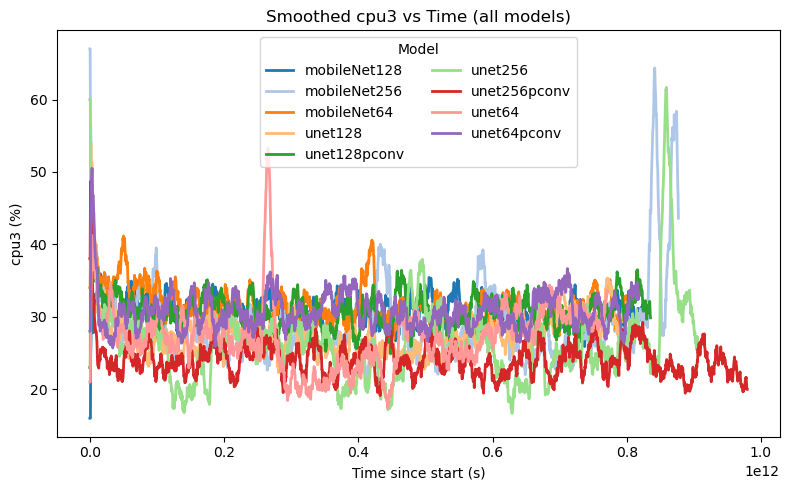

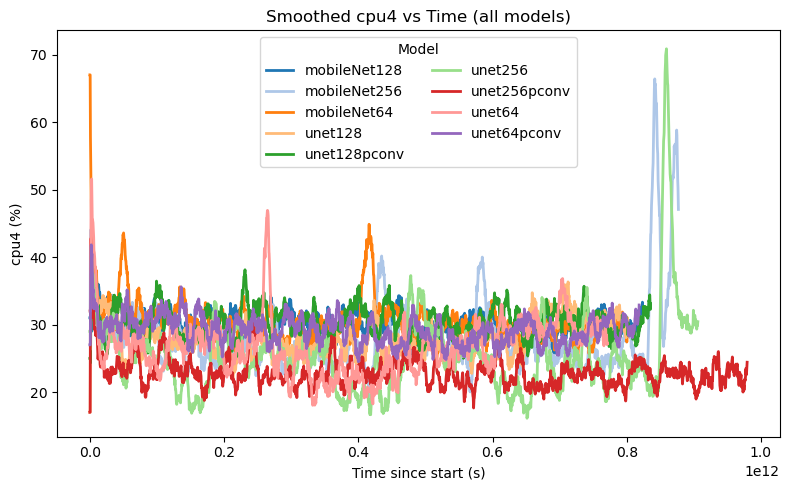

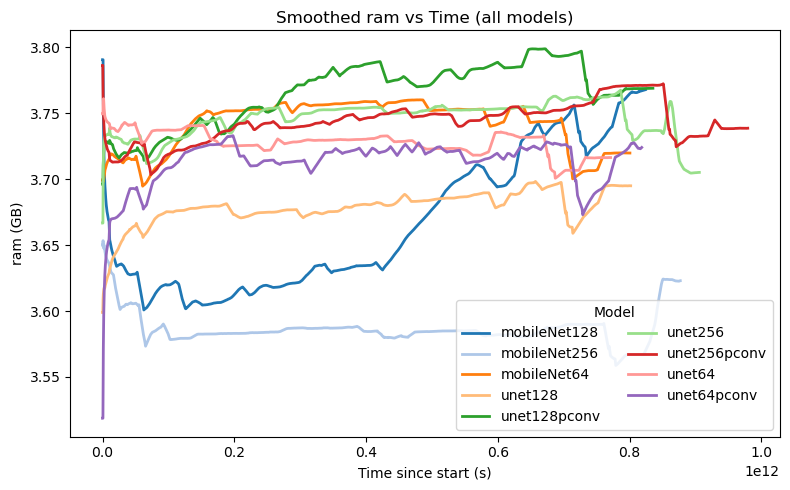

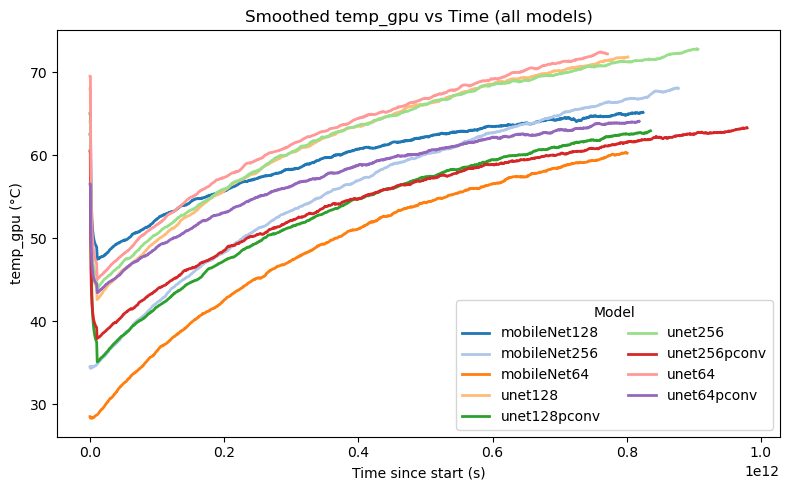

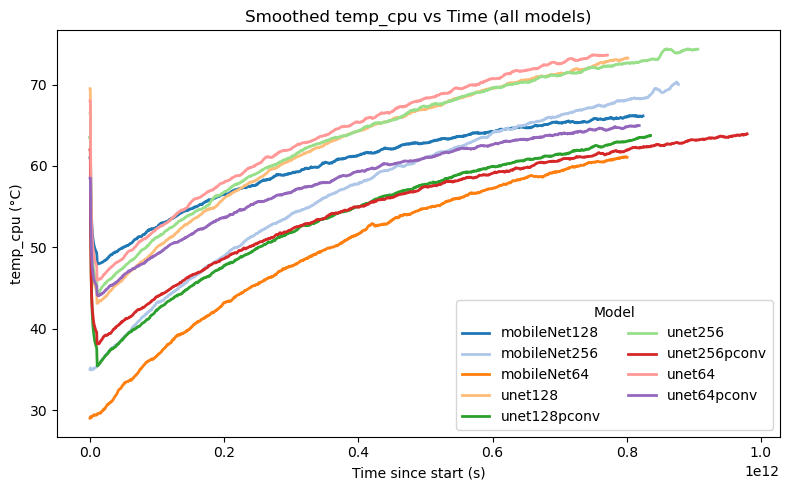

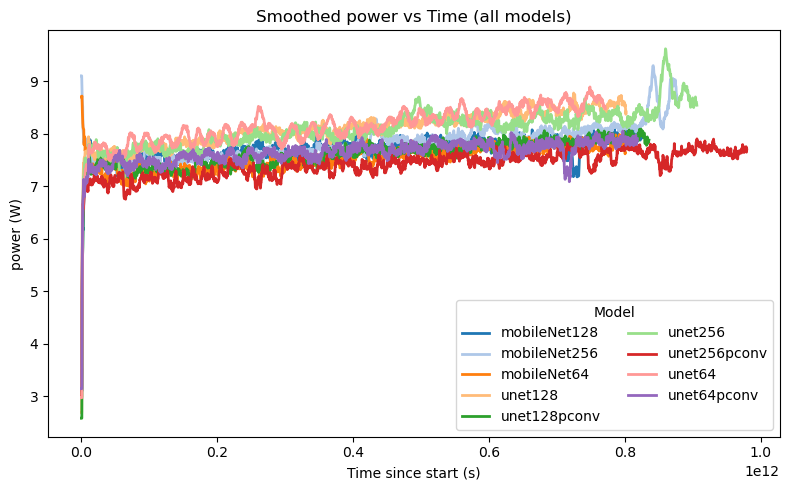

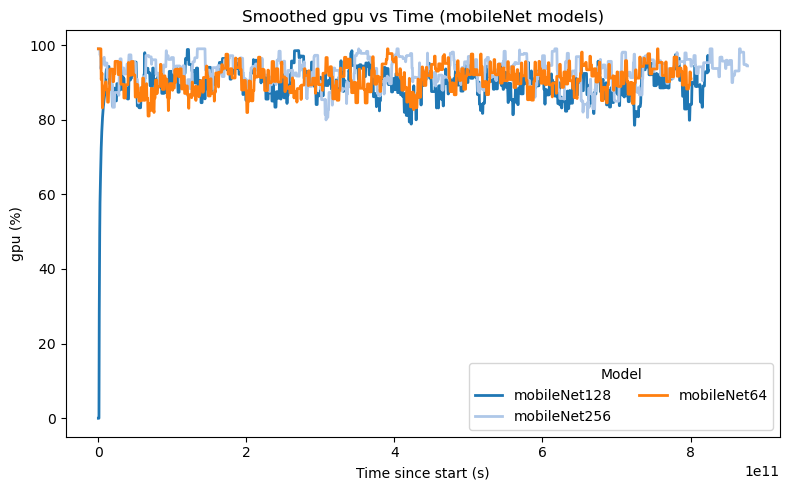

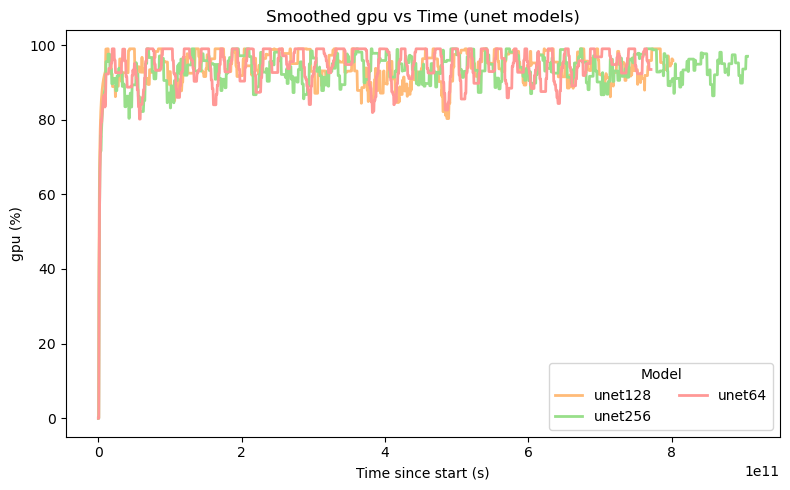

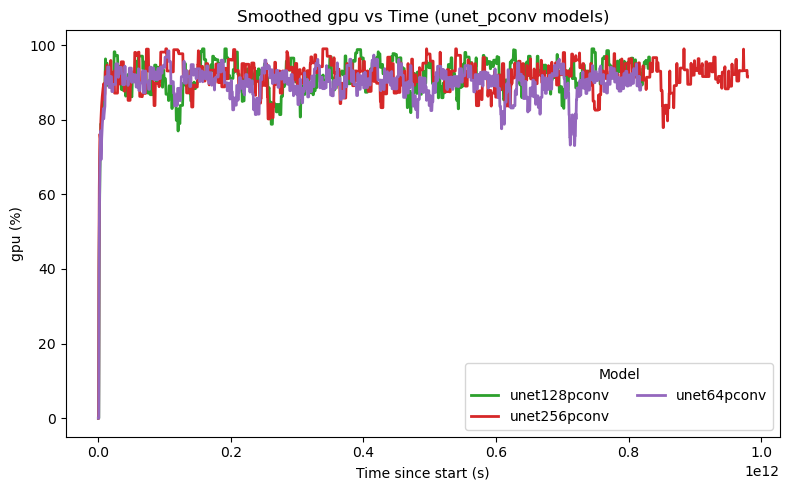

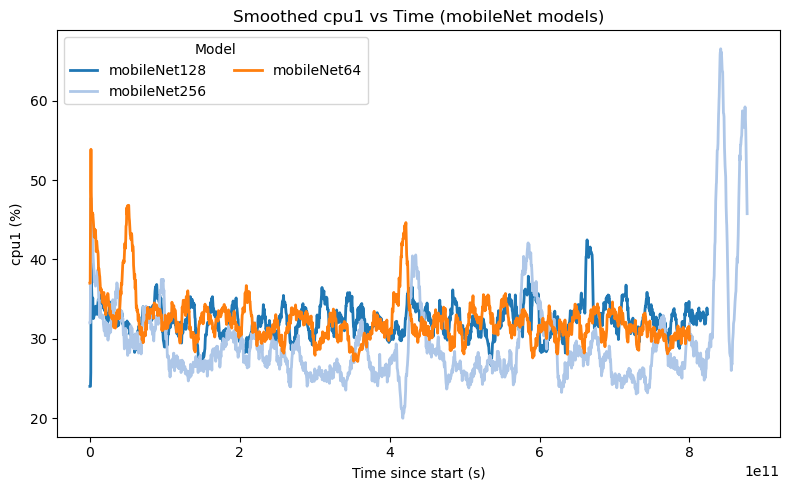

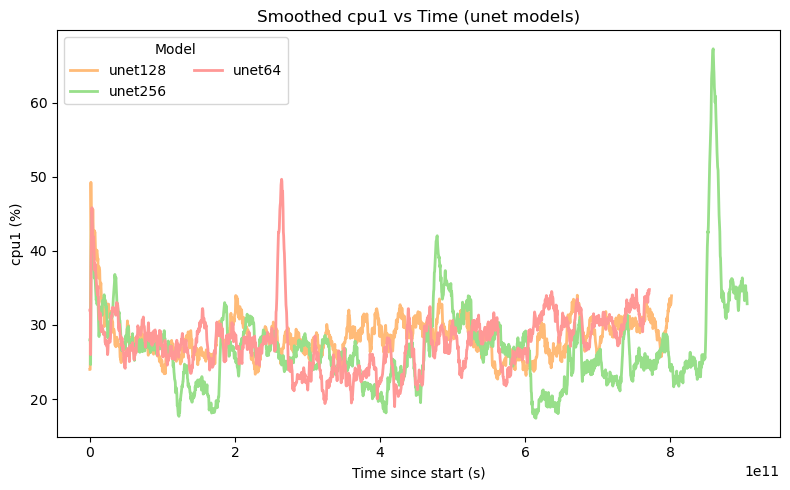

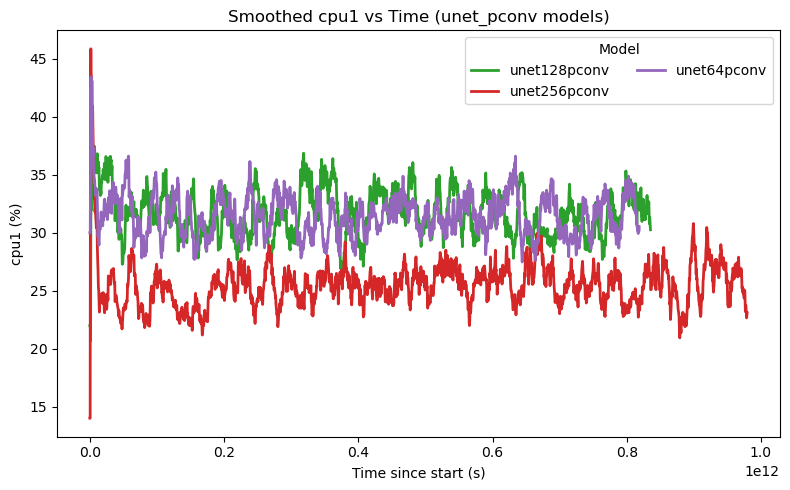

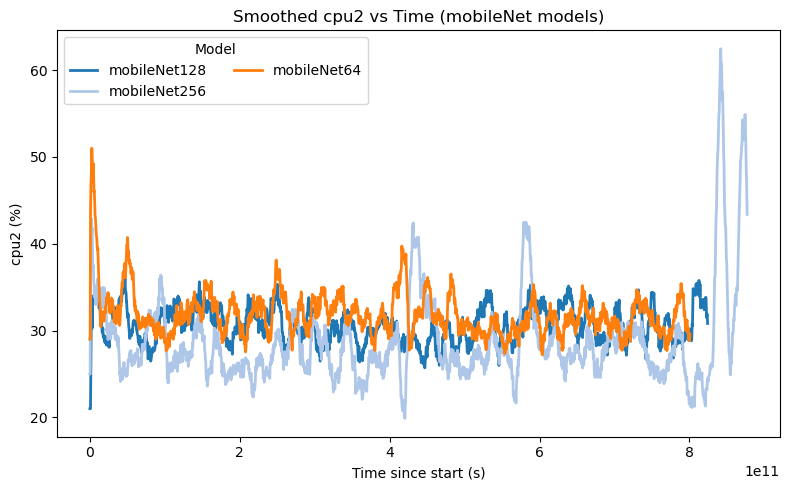

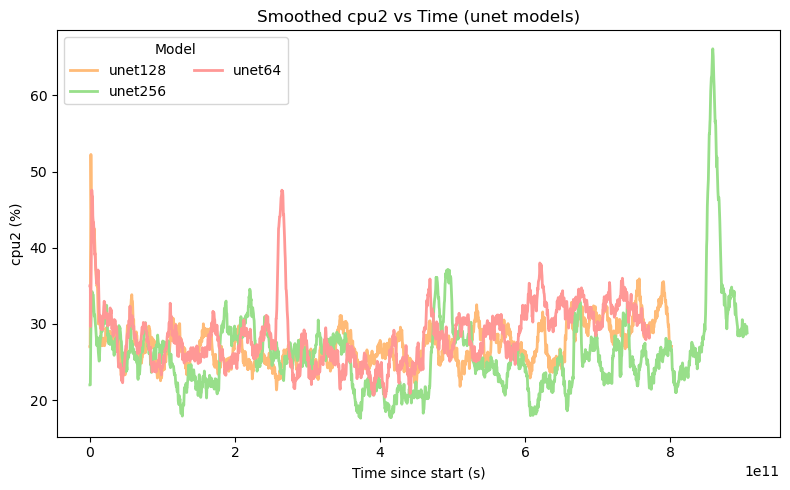

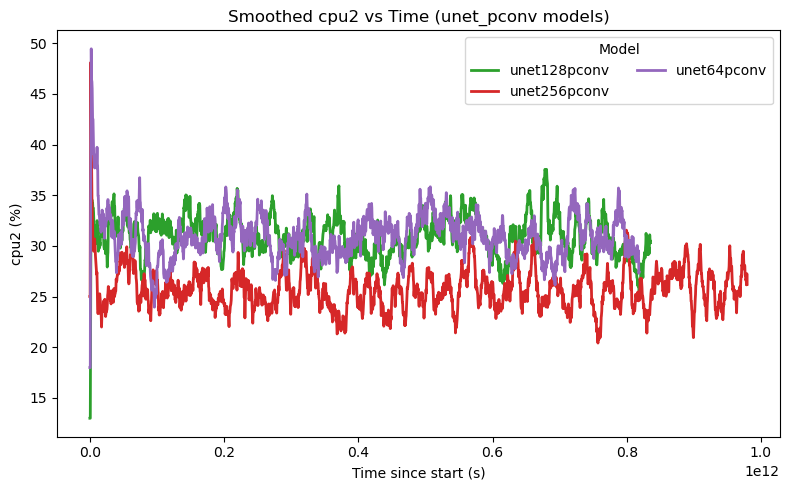

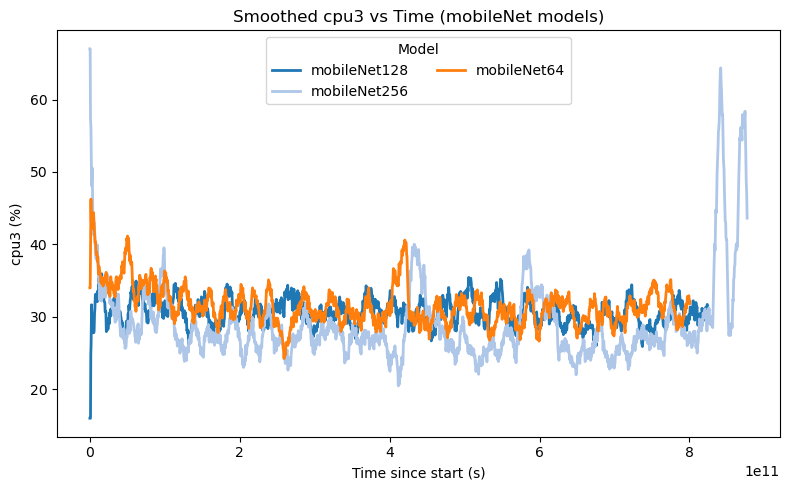

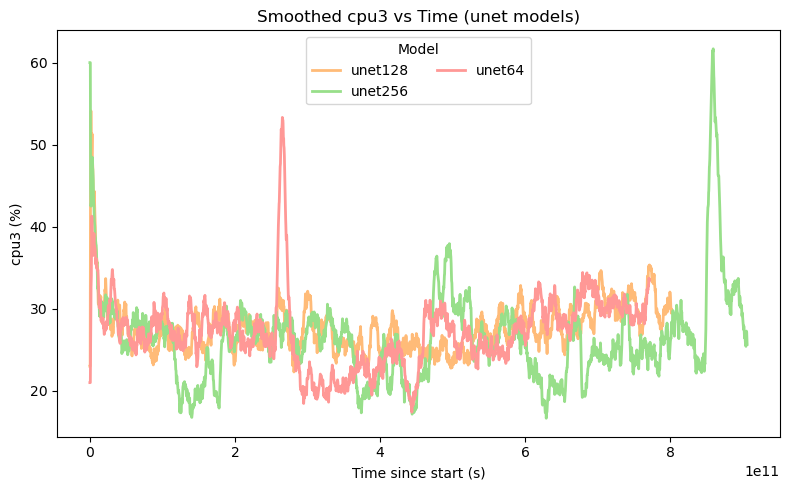

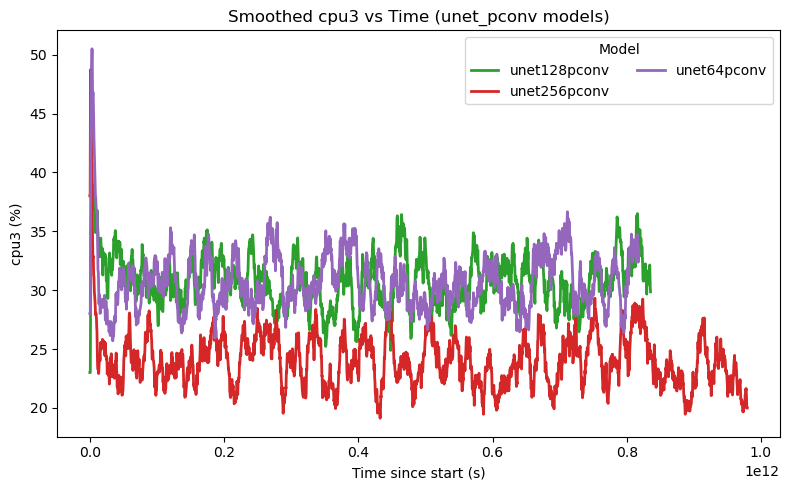

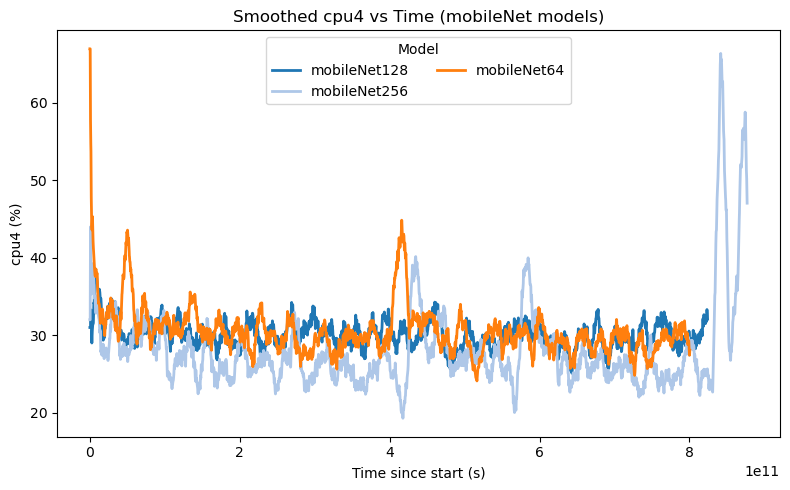

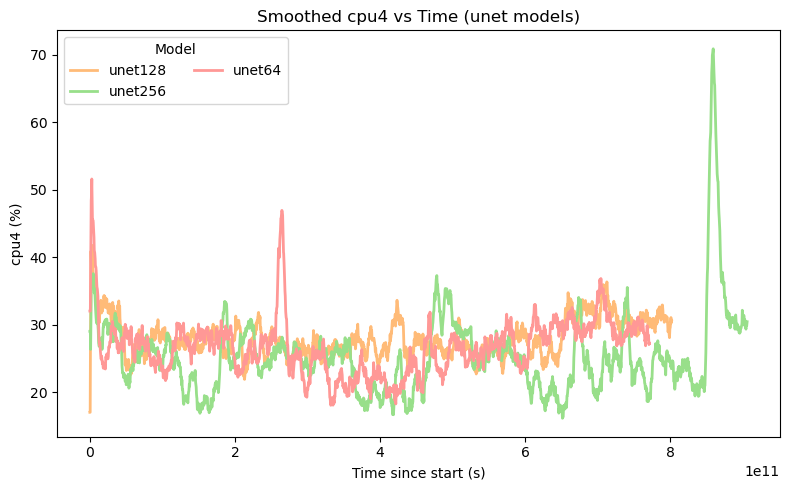

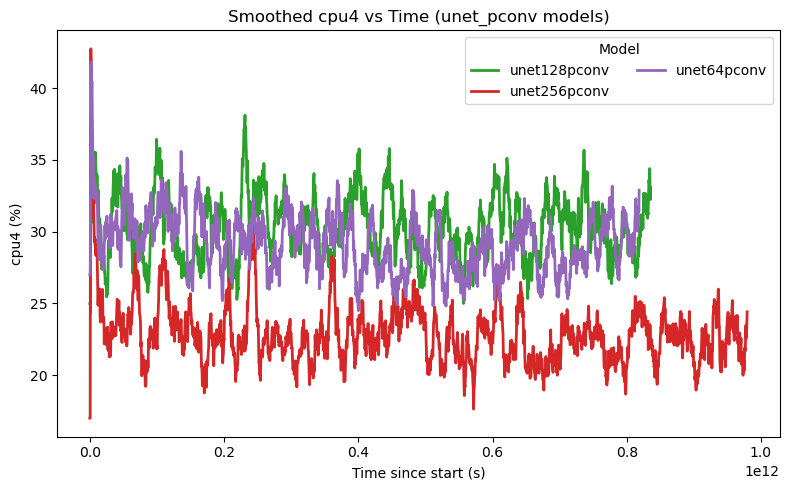

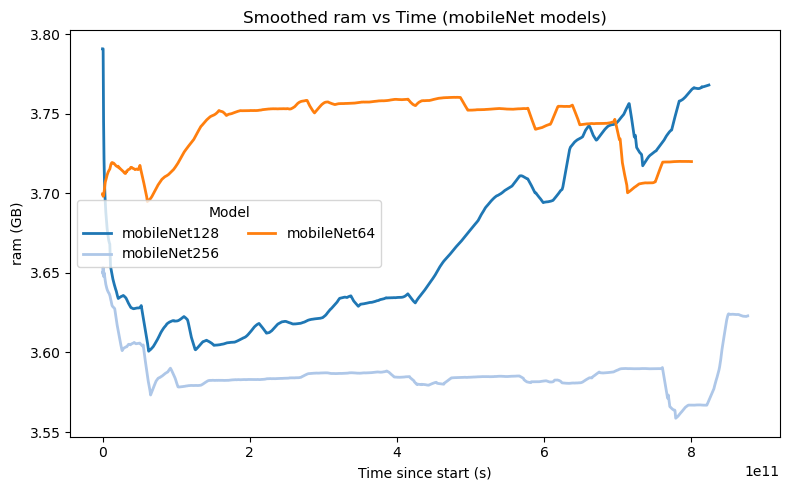

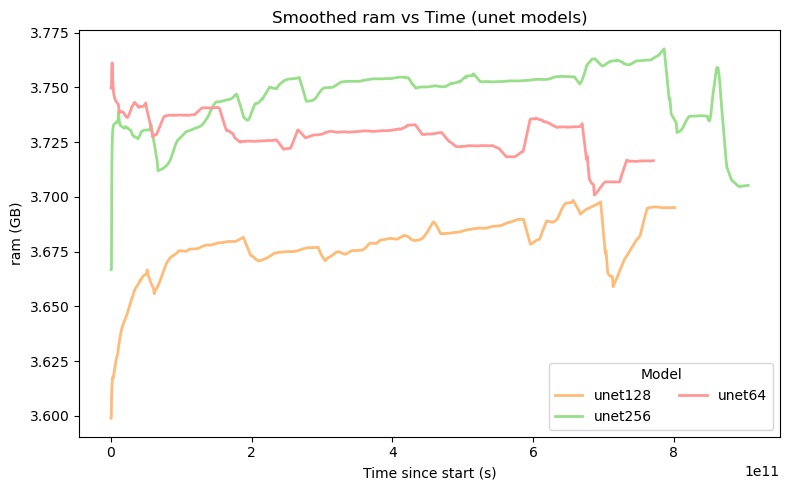

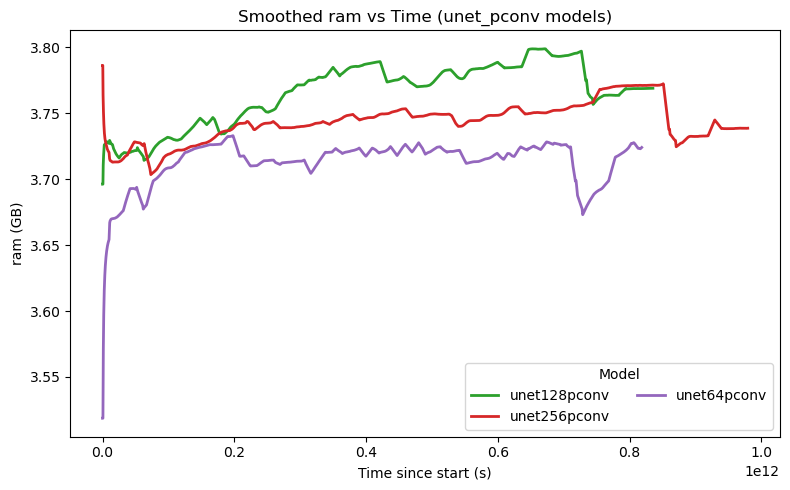

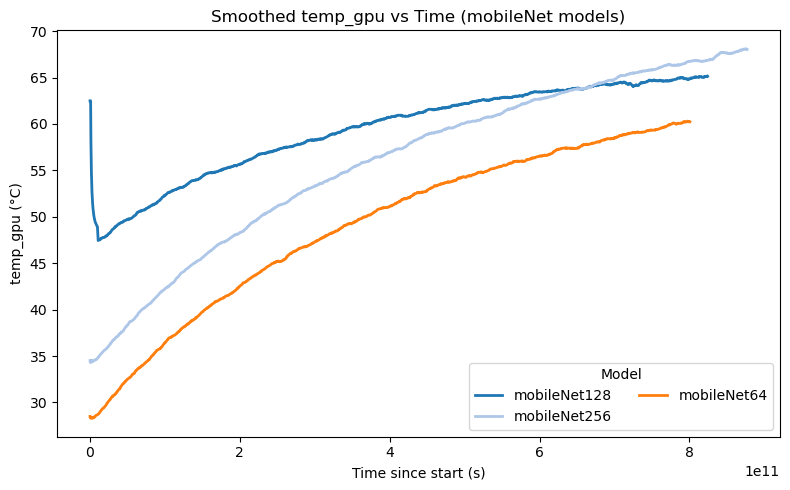

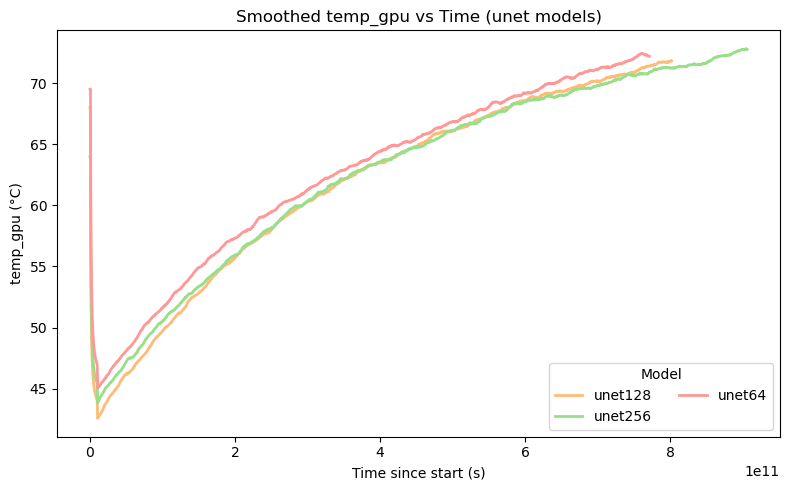

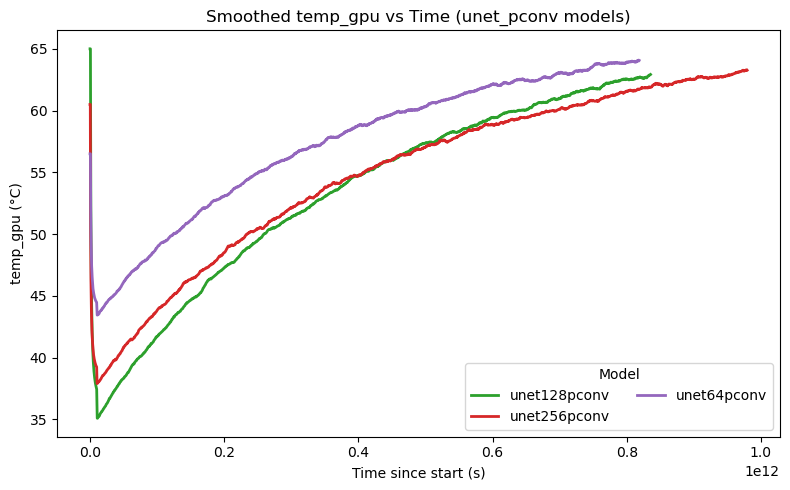

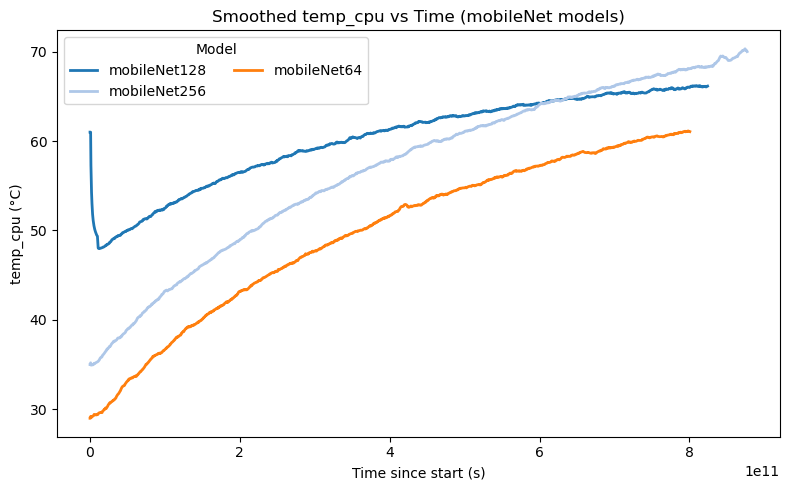

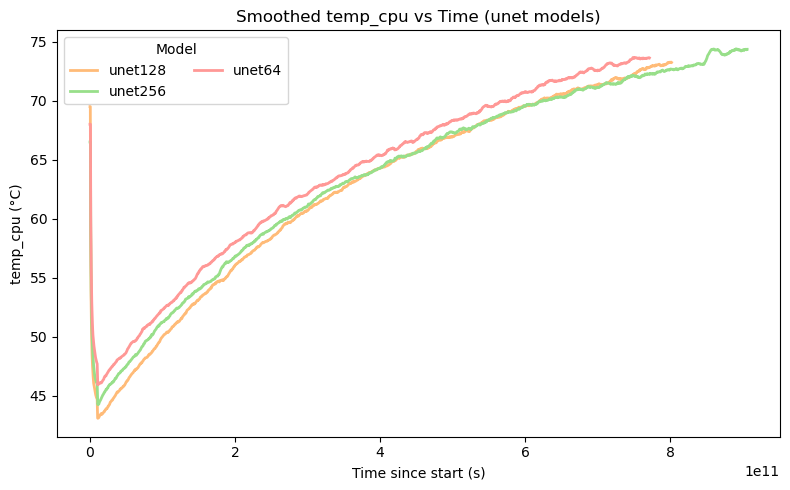

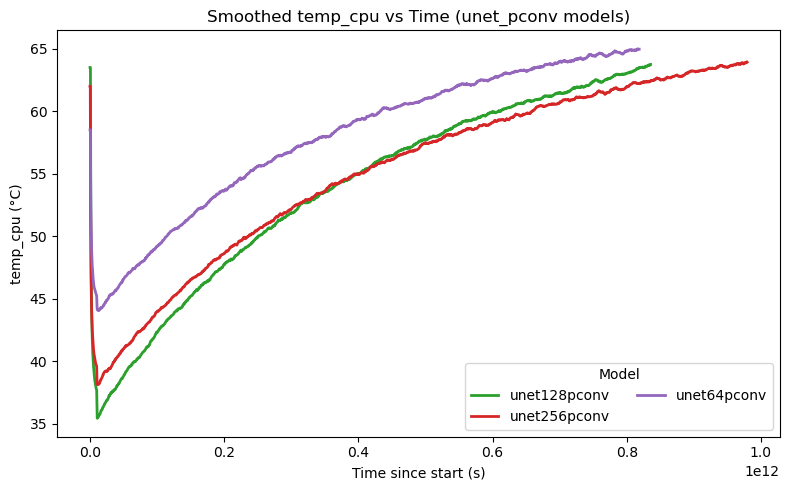

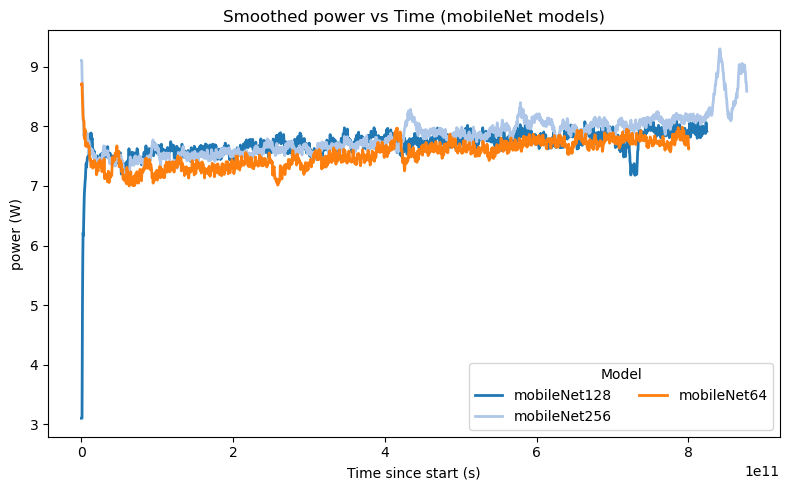

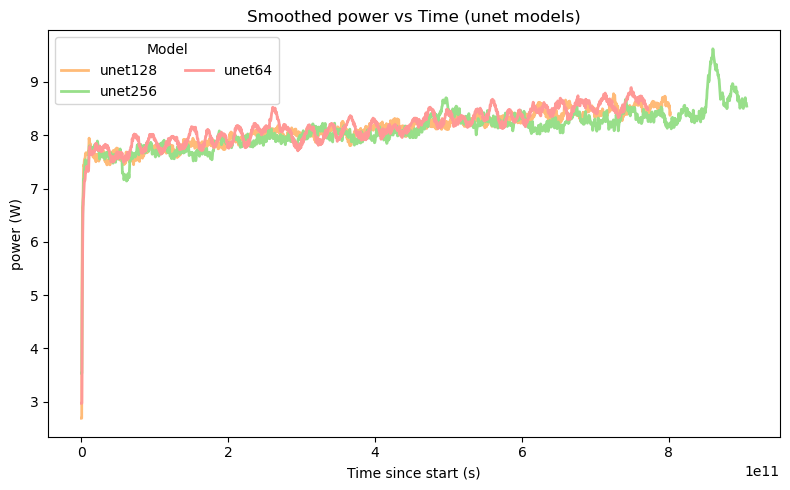

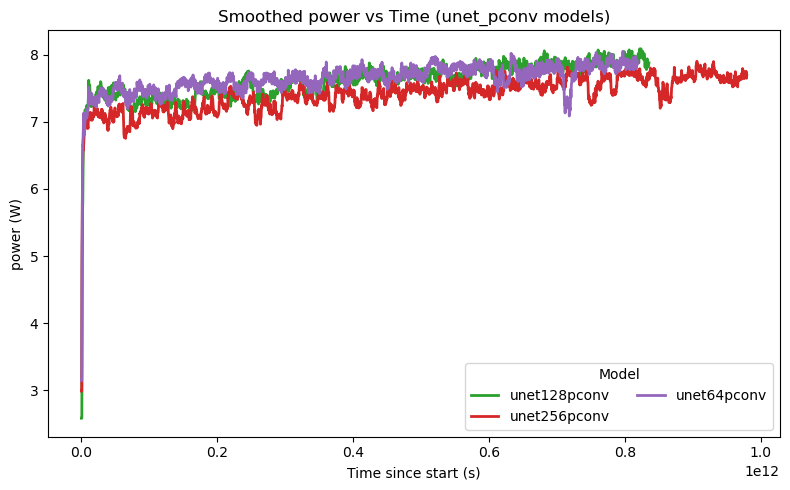

In [211]:
import matplotlib.pyplot as plt

# Define units for each variable
units = {
    "gpu": "%",
    "cpu1": "%",
    "cpu2": "%",
    "cpu3": "%",
    "cpu4": "%",
    "ram": "GB",
    "temp_gpu": "°C",
    "temp_cpu": "°C",
    "power": "W"
}

groups = {
    "mobileNet": [m for m in data.keys() if m.startswith("mobileNet")],
    "unet": [m for m in data.keys() if m.startswith("unet") and "pconv" not in m],
    "unet_pconv": [m for m in data.keys() if "pconv" in m]
}


# --- Existing plots (all models) ---
for var in variables:
    plt.figure(figsize=(8,5))
    for model, df in data.items():
        if f"{var}_smooth" in df.columns:
            plt.plot(df.index, df[f"{var}_smooth"], label=model, color=color_map[model], linewidth=2)
    plt.xlabel("Time since start (s)")
    plt.ylabel(f"{var} ({units.get(var, '')})")  # Add units here
    plt.title(f"Smoothed {var} vs Time (all models)")
    plt.legend(title="Model", ncol=2)
    plt.tight_layout()
    plt.show()

# --- Grouped plots ---
for var in variables:
    for group_name, model_list in groups.items():
        plt.figure(figsize=(8,5))
        for model in model_list:
            df = data[model]
            if f"{var}_smooth" in df.columns:
                plt.plot(df.index, df[f"{var}_smooth"], label=model, color=color_map[model], linewidth=2)
        plt.xlabel("Time since start (s)")
        plt.ylabel(f"{var} ({units.get(var, '')})")  # Add units here
        plt.title(f"Smoothed {var} vs Time ({group_name} models)")
        plt.legend(title="Model", ncol=2)
        plt.tight_layout()
        plt.show()


## Everything2

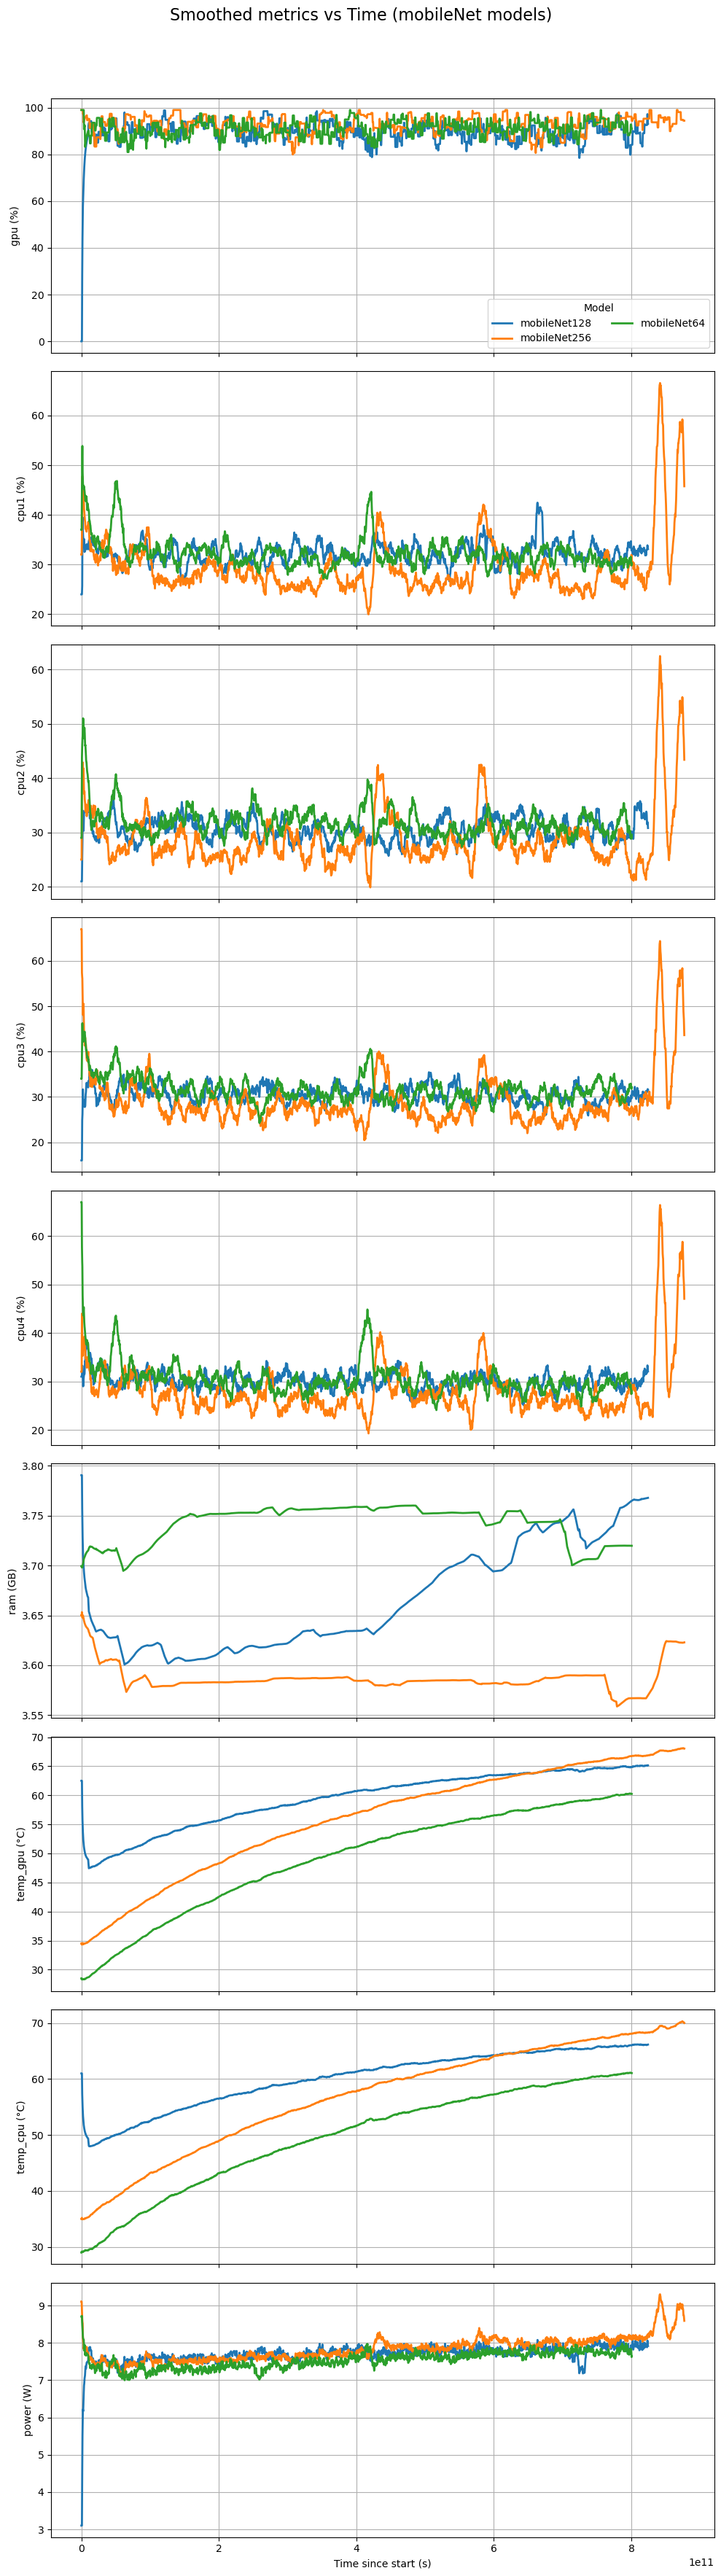

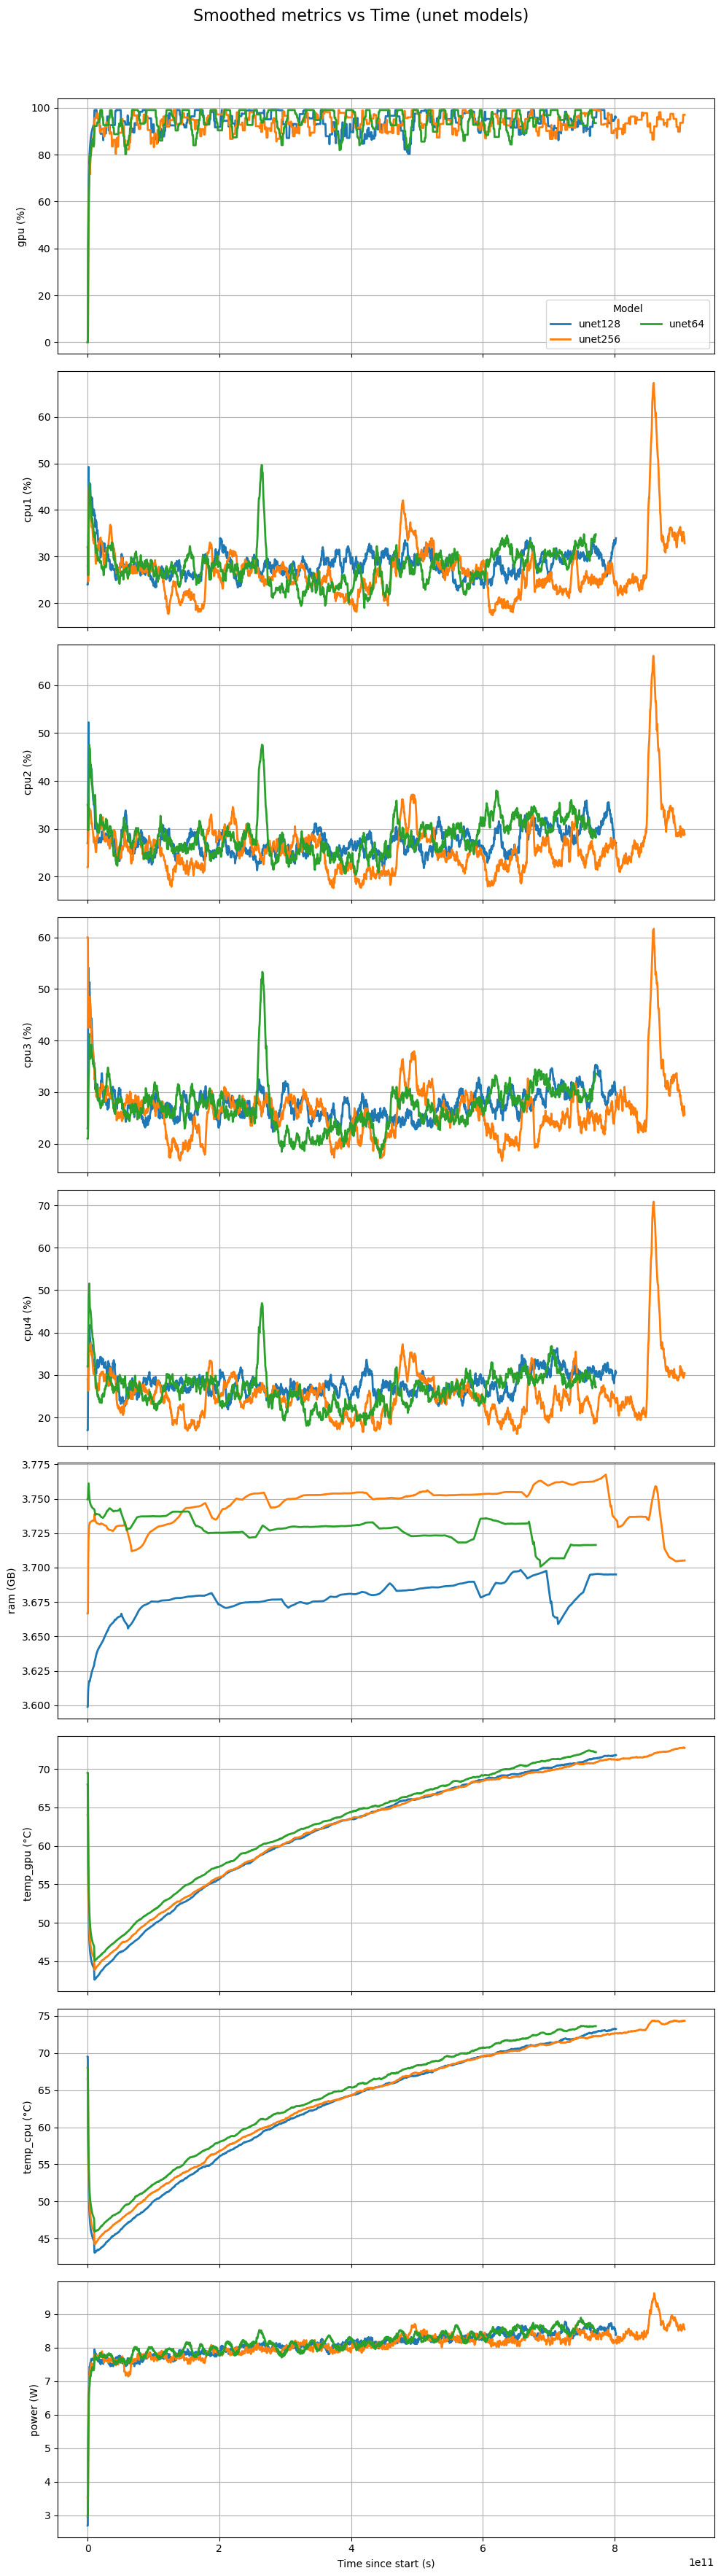

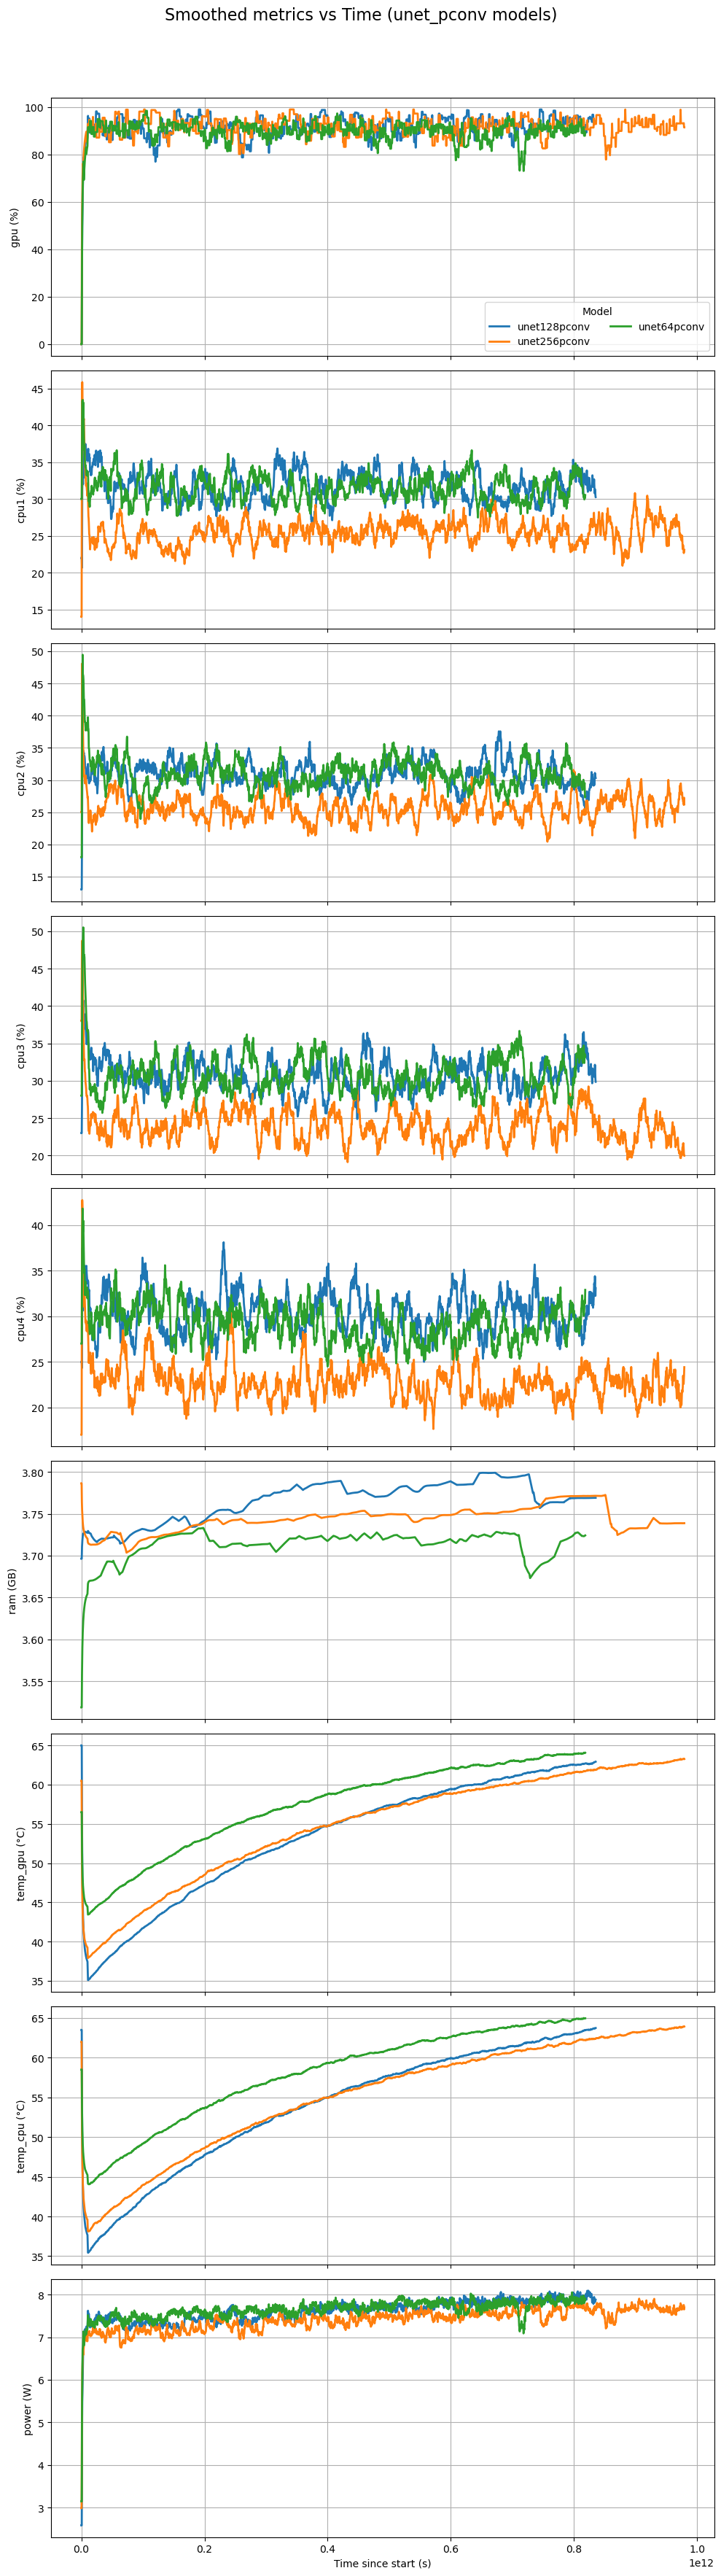

In [212]:
# Example: Plot all variables for each group in one figure
for group_name, model_list in groups.items():
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 1, figsize=(10, 4*n_vars), sharex=True)  # stacked vertically
    fig.suptitle(f"Smoothed metrics vs Time ({group_name} models)", fontsize=16)

    for i, var in enumerate(variables):
        ax = axes[i]
        for model in model_list:
            df = data[model]
            if f"{var}_smooth" in df.columns:
                ax.plot(df.index, df[f"{var}_smooth"], label=model, linewidth=2)
        ax.set_ylabel(f"{var} ({units.get(var, '')})")
        ax.grid(True)
        if i == n_vars - 1:
            ax.set_xlabel("Time since start (s)")

    axes[0].legend(title="Model", ncol=2)  # only show legend on first subplot
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
    plt.show()

## Everything3

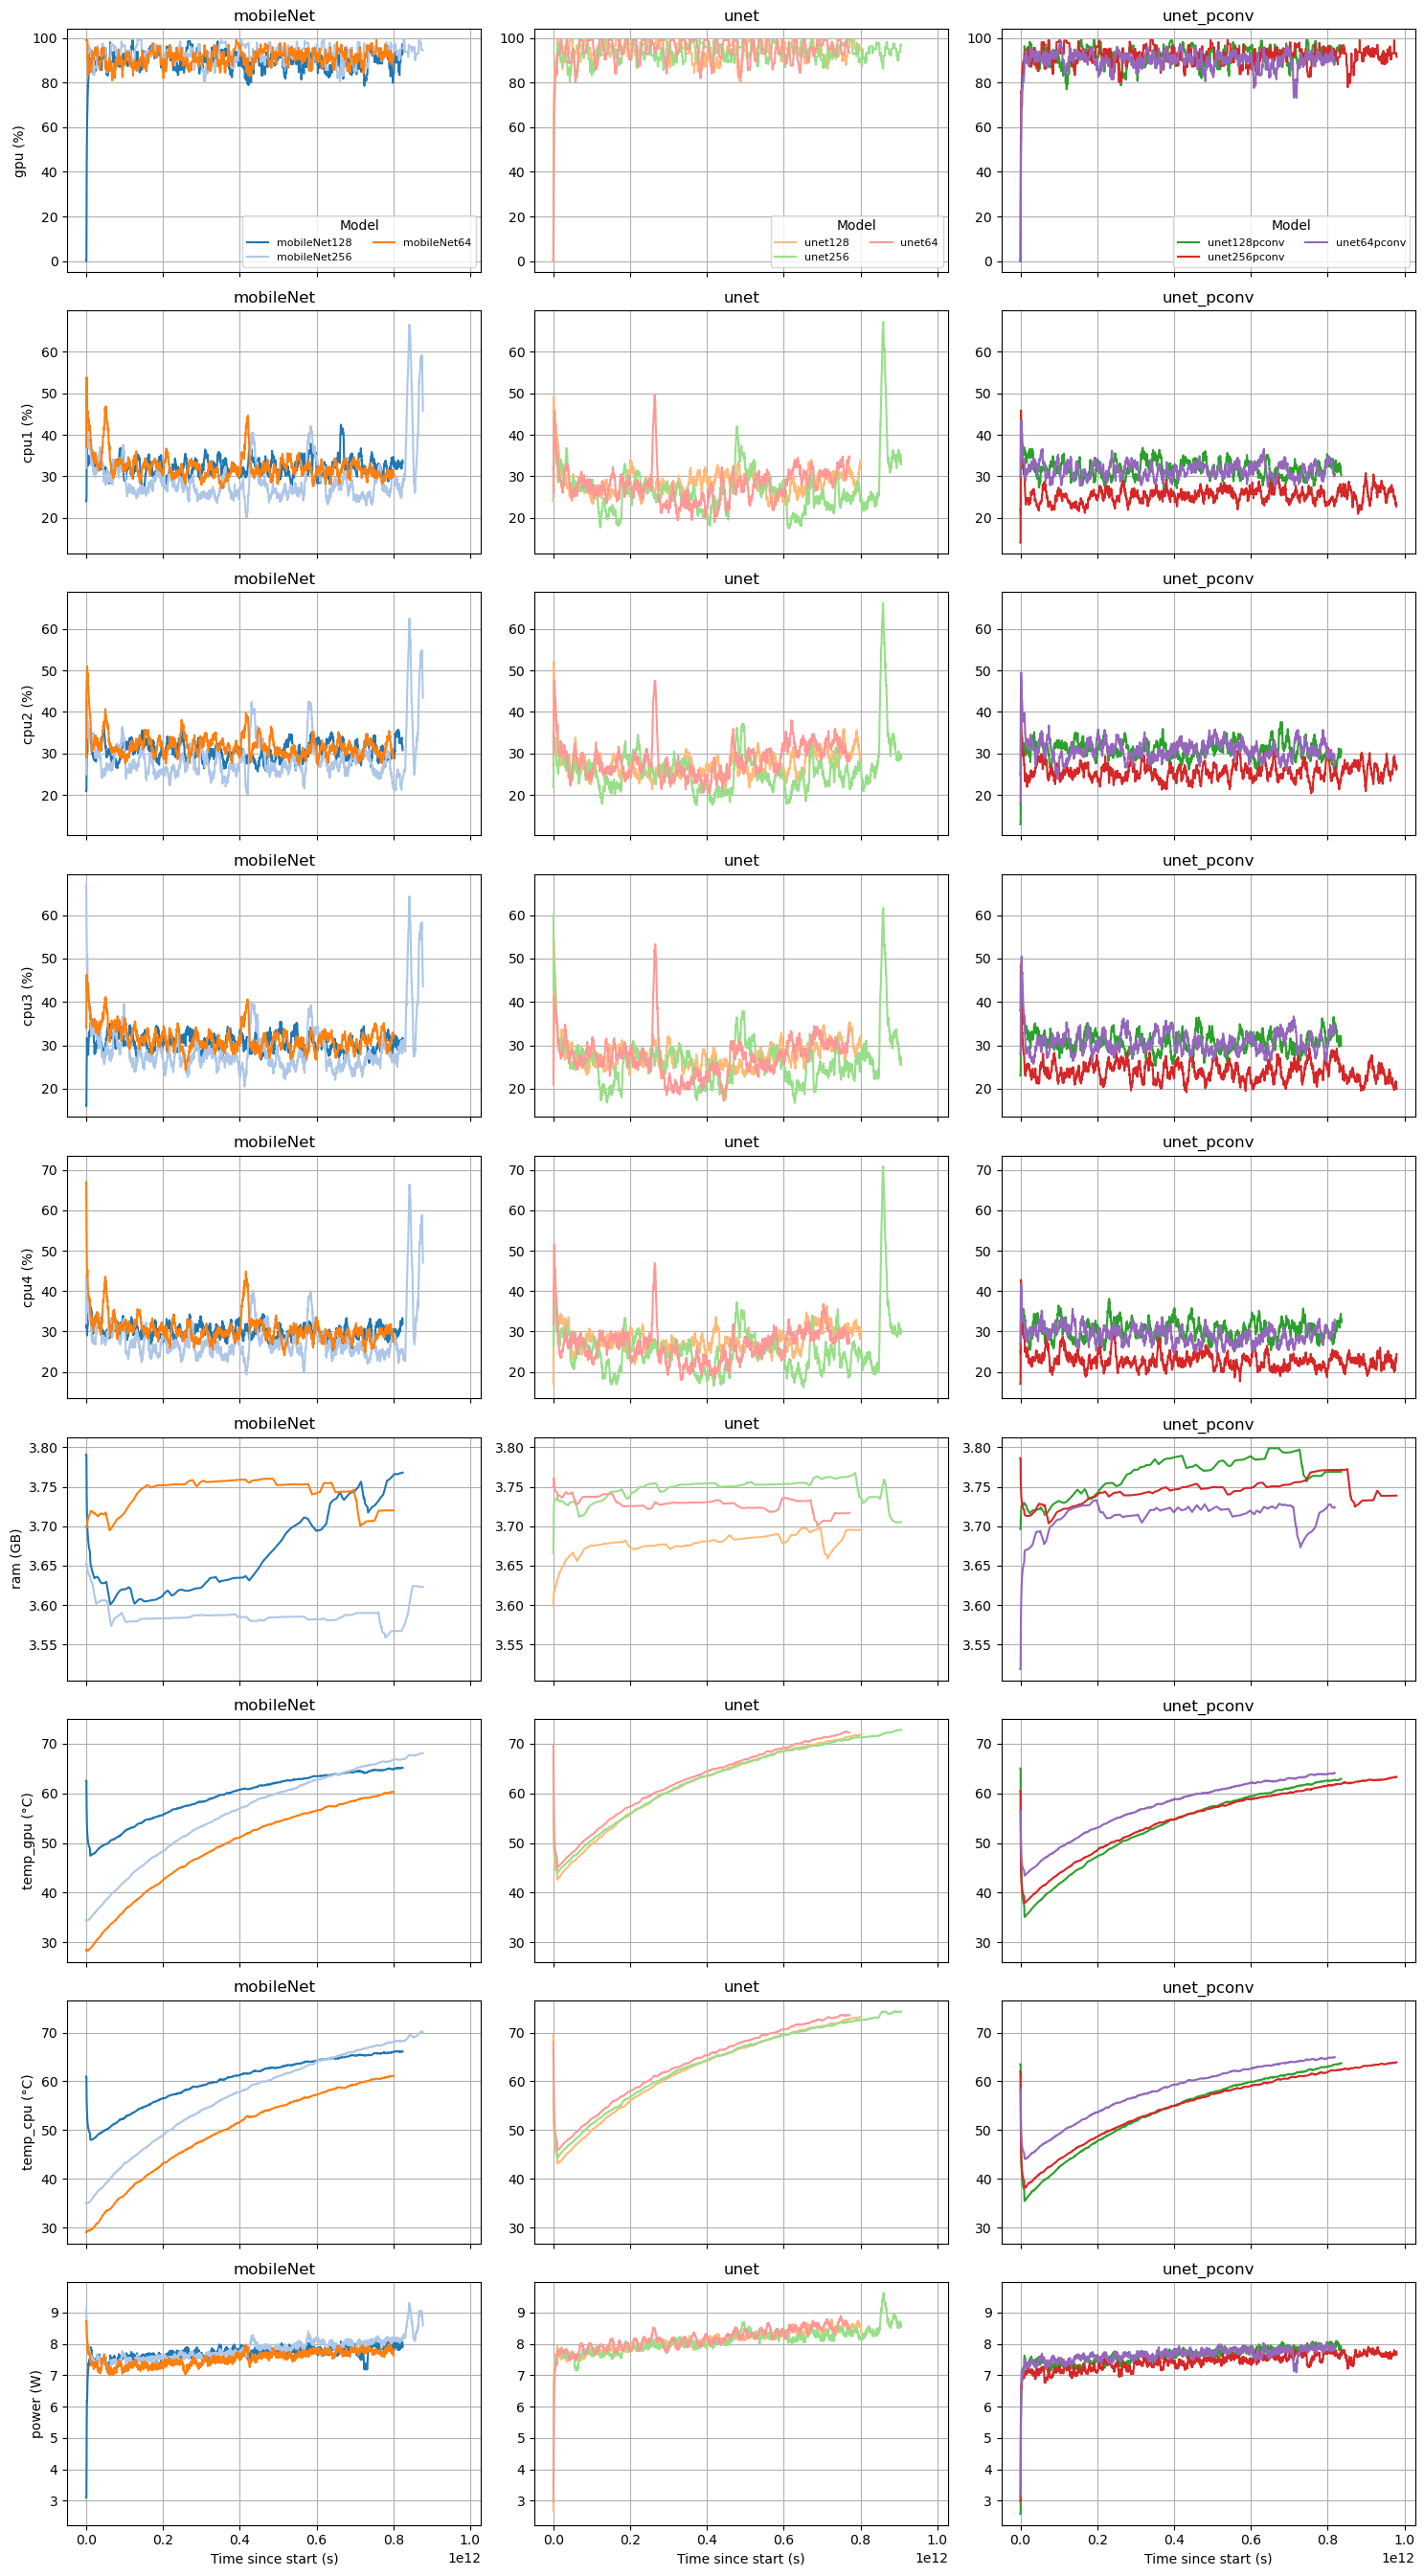

In [213]:
import matplotlib.pyplot as plt
import numpy as np

# Units for y-axis
units = {
    "gpu": "%",
    "cpu1": "%",
    "cpu2": "%",
    "cpu3": "%",
    "cpu4": "%",
    "ram": "GB",
    "temp_gpu": "°C",
    "temp_cpu": "°C",
    "power": "W"
}

variables = ["gpu", "cpu1", "cpu2", "cpu3", "cpu4", "ram", "temp_gpu", "temp_cpu", "power"]
groups = {
    "mobileNet": [m for m in data.keys() if m.startswith("mobileNet")],
    "unet": [m for m in data.keys() if m.startswith("unet") and "pconv" not in m],
    "unet_pconv": [m for m in data.keys() if "pconv" in m]
}

colors = plt.cm.tab20(range(len(data)))
color_map = dict(zip(data.keys(), colors))

n_vars = len(variables)
n_groups = len(groups)
fig, axes = plt.subplots(n_vars, n_groups, figsize=(5*n_groups, 3*n_vars), sharex=True)

# Precompute y-limits per variable
y_limits = {}
for var in variables:
    all_values = []
    for model in data:
        df = data[model]
        if f"{var}_smooth" in df.columns:
            all_values.extend(df[f"{var}_smooth"].values)
    if all_values:  # only if there is data
        min_val = np.min(all_values)
        max_val = np.max(all_values)
        margin = (max_val - min_val) * 0.05  # 5% margin
        y_limits[var] = (min_val - margin, max_val + margin)
    else:
        y_limits[var] = (0, 1)  # fallback

# Plot
for i, var in enumerate(variables):
    for j, (group_name, model_list) in enumerate(groups.items()):
        ax = axes[i, j] if n_vars > 1 else axes[j]  # handle single variable edge case
        for model in model_list:
            df = data[model]
            if f"{var}_smooth" in df.columns:
                ax.plot(df.index, df[f"{var}_smooth"], label=model, color=color_map[model], linewidth=1.5)
        ax.set_ylim(y_limits[var])  # enforce consistent y-axis per variable
        if i == n_vars - 1:
            ax.set_xlabel("Time since start (s)")
        if j == 0:
            ax.set_ylabel(f"{var} ({units.get(var, '')})")
        ax.set_title(group_name)
        ax.grid(True)

# Legends
for j, (group_name, model_list) in enumerate(groups.items()):
    axes[0, j].legend(title="Model", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


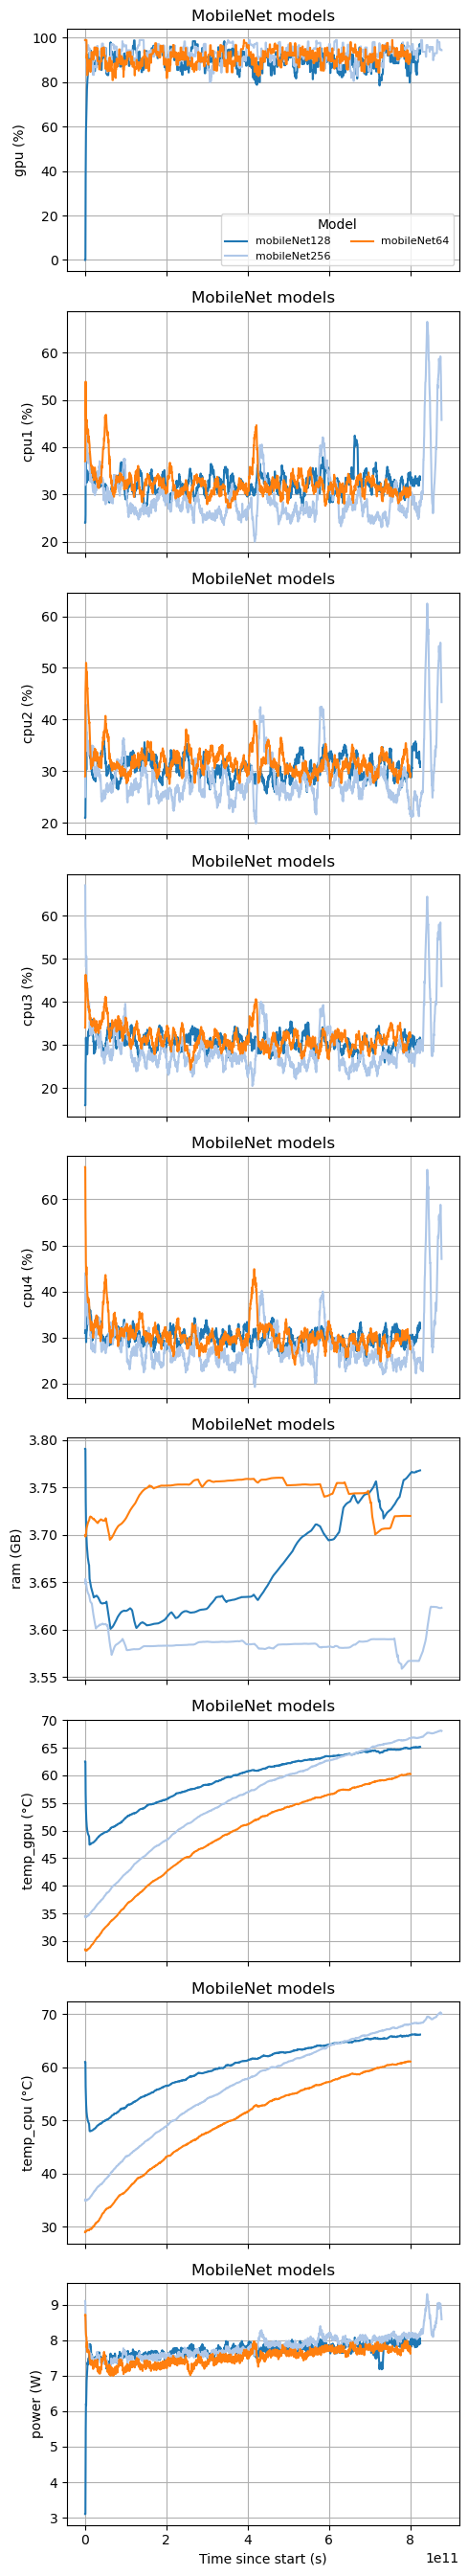

In [223]:
import matplotlib.pyplot as plt
import numpy as np

# Units for y-axis
units = {
    "gpu": "%",
    "cpu1": "%",
    "cpu2": "%",
    "cpu3": "%",
    "cpu4": "%",
    "ram": "GB",
    "temp_gpu": "°C",
    "temp_cpu": "°C",
    "power": "W"
}

variables = ["gpu", "cpu1", "cpu2", "cpu3", "cpu4", "ram", "temp_gpu", "temp_cpu", "power"]

# Only MobileNet models
mobile_models = [m for m in data.keys() if m.startswith("mobileNet")]

# Prepare colors for 6 models
colors = plt.cm.tab20(range(len(mobile_models)))
color_map = dict(zip(mobile_models, colors))

n_vars = len(variables)
n_groups = 1  # Only one group (MobileNet)
fig, axes = plt.subplots(n_vars, n_groups, figsize=(5*n_groups, 3*n_vars), sharex=True)

# Precompute y-limits per variable for MobileNet models only
y_limits = {}
for var in variables:
    all_values = []
    for model in mobile_models:
        df = data[model]
        if f"{var}_smooth" in df.columns:
            all_values.extend(df[f"{var}_smooth"].values)
    if all_values:
        min_val = np.min(all_values)
        max_val = np.max(all_values)
        margin = (max_val - min_val) * 0.05
        y_limits[var] = (min_val - margin, max_val + margin)
    else:
        y_limits[var] = (0, 1)

# Plot each variable
for i, var in enumerate(variables):
    ax = axes[i] if n_vars > 1 else axes
    for model in mobile_models:
        df = data[model]
        if f"{var}_smooth" in df.columns:
            ax.plot(df.index, df[f"{var}_smooth"], label=model, color=color_map[model], linewidth=1.5)
    ax.set_ylim(y_limits[var])
    if i == n_vars - 1:
        ax.set_xlabel("Time since start (s)")
    ax.set_ylabel(f"{var} ({units.get(var, '')})")
    ax.set_title("MobileNet models")
    ax.grid(True)

# Legend only once
axes[0].legend(title="Model", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


# Latency

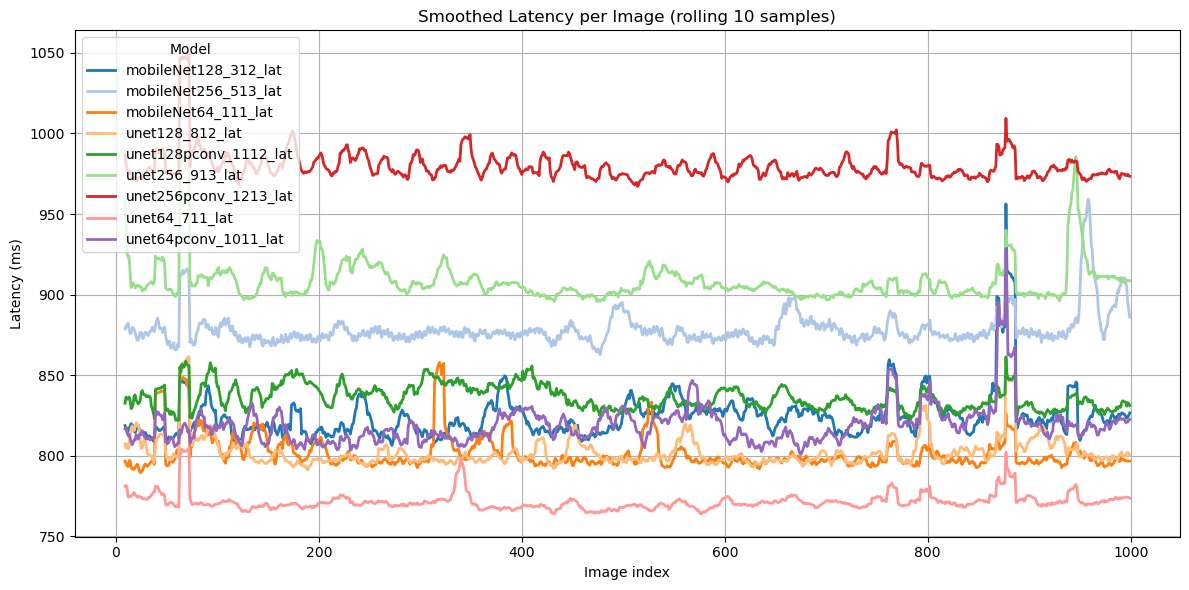

In [214]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

data_path = Path(r"C:\Users\Daniel K\Desktop\DAKI\3. Semester\P3\Nvidia_Jetson_p3\inference_data")  # adjust your path

# --- Load latency files ---
lat_files = sorted(f for f in data_path.glob("*.csv") if f.stem.endswith("_lat")and f.stem[-6] == "1")

data_lat = {}
for f in lat_files:
    df = pd.read_csv(f)
    # Optional: convert image column to index for plotting
    df.index = np.arange(len(df))
    data_lat[f.stem] = df

# --- Define smoothing ---
TIME_WINDOW = 10  # rolling window in number of samples
for model, df in data_lat.items():
    df["latency_smooth"] = df["latency_ms"].rolling(TIME_WINDOW).mean()
    data_lat[model] = df

# --- Prepare colors ---
models = sorted(data_lat.keys())
colors = plt.cm.tab20(range(len(models)))
color_map = dict(zip(models, colors))

# --- Plot all latencies in one figure ---
plt.figure(figsize=(12,6))
for model in models:
    df = data_lat[model]
    plt.plot(df.index, df["latency_smooth"], label=model, color=color_map[model], linewidth=2)
plt.xlabel("Image index")
plt.ylabel("Latency (ms)")
plt.title(f"Smoothed Latency per Image (rolling {TIME_WINDOW} samples)")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()


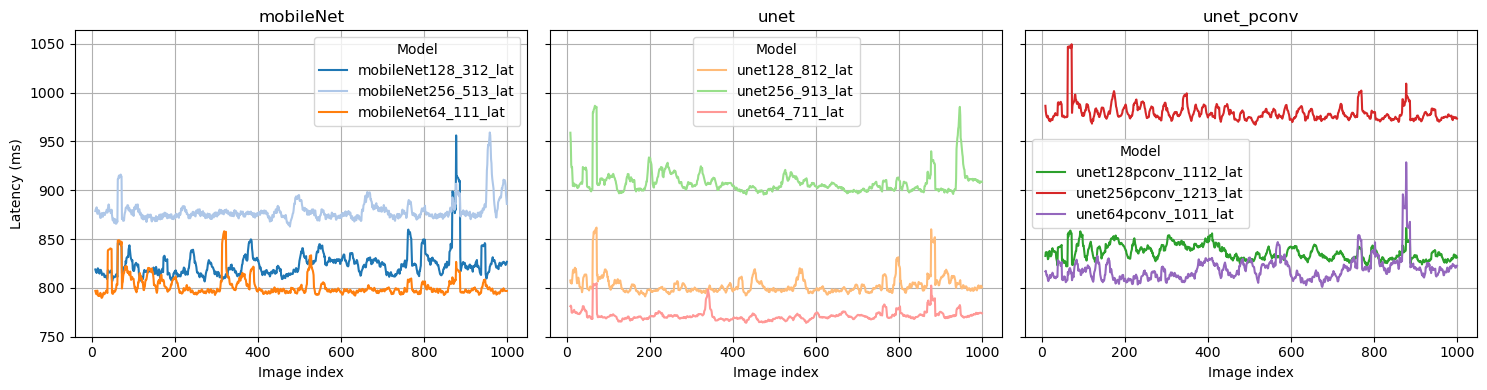

In [215]:
groups = {
    "mobileNet": [m for m in data_lat.keys() if "mobileNet" in m],
    "unet": [m for m in data_lat.keys() if "unet" in m and "pconv" not in m],
    "unet_pconv": [m for m in data_lat.keys() if "pconv" in m]
}

n_groups = len(groups)
fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups,4), sharey=True)

for j, (group_name, model_list) in enumerate(groups.items()):
    ax = axes[j] if n_groups > 1 else axes
    for model in model_list:
        df = data_lat[model]
        ax.plot(df.index, df["latency_smooth"], label=model, color=color_map[model])
    ax.set_title(group_name)
    ax.set_xlabel("Image index")
    if j == 0:
        ax.set_ylabel("Latency (ms)")
    ax.grid(True)
    ax.legend(title="Model")

plt.tight_layout()
plt.show()


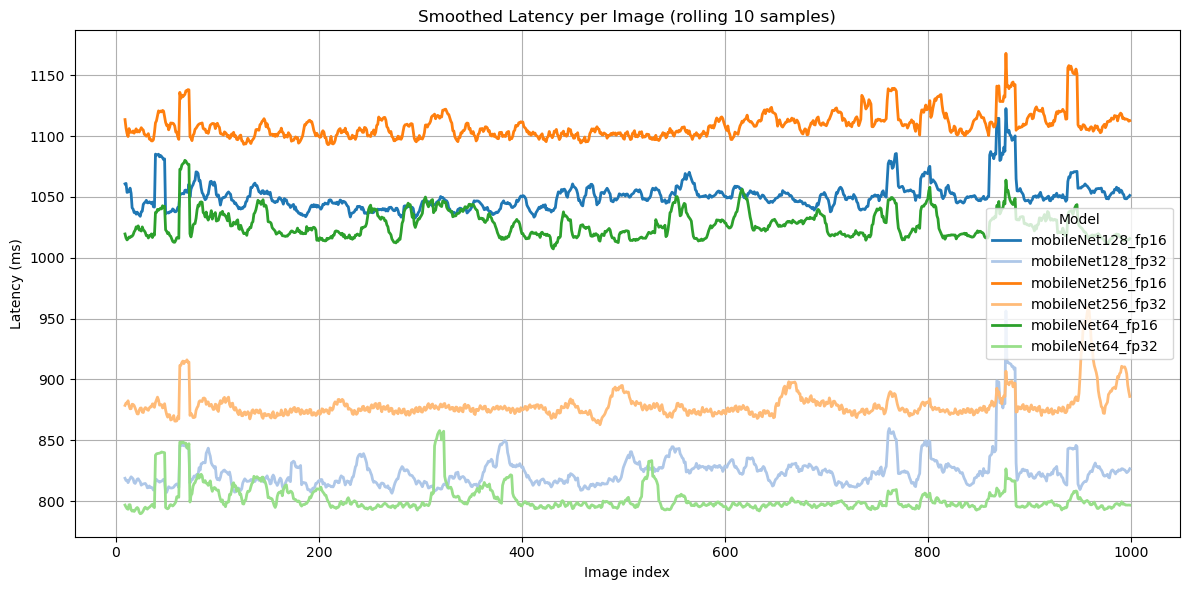

In [216]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

data_path = Path(r"C:\Users\Daniel K\Desktop\DAKI\3. Semester\P3\Nvidia_Jetson_p3\inference_data")

# --- Load latency files ---
lat_files = sorted(f for f in data_path.glob("*.csv") if f.stem.endswith("_lat") and f.stem.startswith("mobileNet"))

data_lat = {}
for f in lat_files:
    df = pd.read_csv(f)
    df.index = np.arange(len(df))
    
    # --- Rename model ---
    base_name = f.stem.split('_')[0]  # take before first "_"
    
    # Add fp32/fp16 based on -6 index
    try:
        if f.stem[-6] == '1':
            base_name += "_fp32"
        elif f.stem[-6] == '2':
            base_name += "_fp16"
    except IndexError:
        # in case the filename is shorter than 6 characters
        pass
    
    data_lat[base_name] = df

# --- Define smoothing ---
TIME_WINDOW = 10
for model, df in data_lat.items():
    df["latency_smooth"] = df["latency_ms"].rolling(TIME_WINDOW).mean()
    data_lat[model] = df

# --- Prepare colors ---
models = sorted(data_lat.keys())
colors = plt.cm.tab20(range(len(models)))
color_map = dict(zip(models, colors))

# --- Plot all latencies in one figure ---
plt.figure(figsize=(12,6))
for model in models:
    df = data_lat[model]
    plt.plot(df.index, df["latency_smooth"], label=model, color=color_map[model], linewidth=2)
plt.xlabel("Image index")
plt.ylabel("Latency (ms)")
plt.title(f"Smoothed Latency per Image (rolling {TIME_WINDOW} samples)")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()


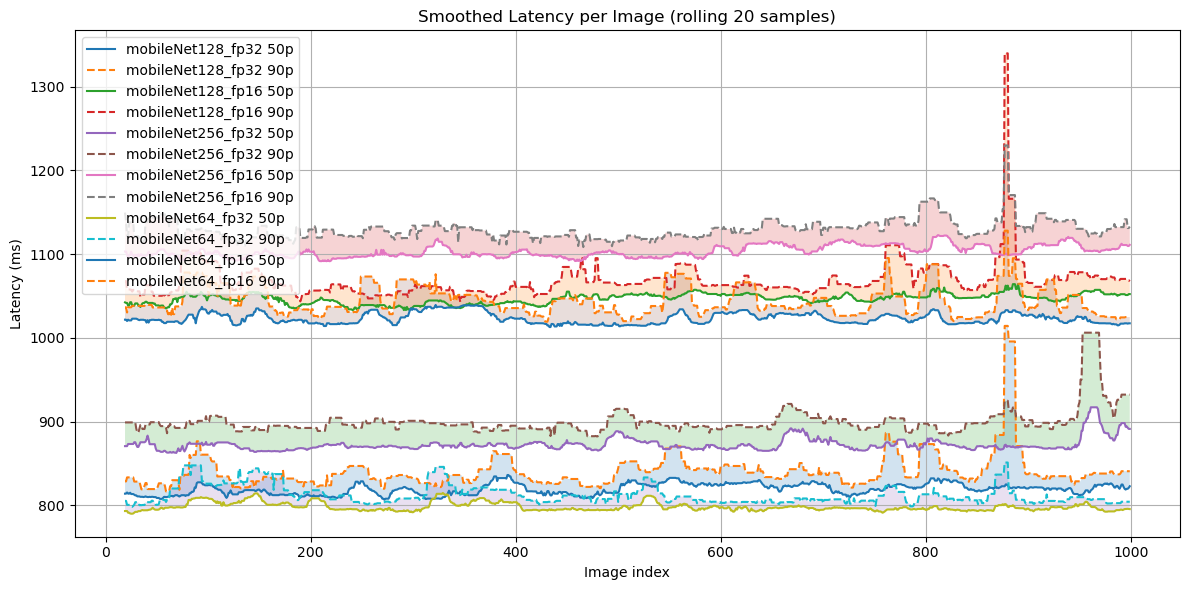

In [218]:
fig, ax = plt.subplots(figsize=(12,6))

window = 20
for model, df in data_lat.items():
    df['lat_50p'] = df['latency_ms'].rolling(window).median()
    df['lat_90p'] = df['latency_ms'].rolling(window).quantile(0.9)
    
    ax.plot(df.index, df['lat_50p'], label=f"{model} 50p")
    ax.plot(df.index, df['lat_90p'], label=f"{model} 90p", linestyle='--')
    ax.fill_between(df.index, df['lat_50p'], df['lat_90p'], alpha=0.2)

ax.set_xlabel("Image index")
ax.set_ylabel("Latency (ms)")
ax.set_title(f"Smoothed Latency per Image (rolling {window} samples)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


# DATA TABLE

In [222]:
import pandas as pd
import re

# List of variables
variables = ["gpu", "cpu1", "cpu2", "cpu3", "cpu4", "ram", "temp_gpu", "temp_cpu", "power"]

# Initialize an empty list to store results
summary_list = []

for model, df in data.items():
    summary_dict = {"Model": model}
    for var in variables:
        if f"{var}_smooth" in df.columns:
            summary_dict[var] = df[f"{var}_smooth"].mean()
        elif var in df.columns:
            summary_dict[var] = df[var].mean()
        else:
            summary_dict[var] = None  # if the variable is missing
    summary_list.append(summary_dict)

# Convert to a DataFrame
summary_df = pd.DataFrame(summary_list)
summary_df = summary_df.round(2)

# --- Define custom sorting key ---
def sort_key(model_name):
    if model_name.startswith("mobileNet"):
        # Extract number after "mobileNet" for ascending order
        num = int(re.findall(r'\d+', model_name)[0])
        return (0, num)
    elif model_name.startswith("unet") and "pconv" not in model_name:
        return (1, 0)  # unet comes after mobileNet
    elif "pconv" in model_name:
        return (2, 0)  # unet_pconv last
    else:
        return (3, 0)  # any other models at the end

# Apply sorting
summary_df = summary_df.sort_values(by="Model", key=lambda x: x.map(sort_key))

# Display table
print(summary_df)


          Model    gpu   cpu1   cpu2   cpu3   cpu4   ram  temp_gpu  temp_cpu  \
2   mobileNet64  90.96  32.31  31.87  31.56  30.55  3.74     48.96     49.54   
0  mobileNet128  89.42  32.29  30.60  30.60  30.09  3.67     59.38     60.12   
1  mobileNet256  93.13  29.47  28.82  29.14  28.13  3.59     56.03     57.02   
3       unet128  93.99  28.50  27.44  27.70  28.04  3.68     61.54     62.24   
5       unet256  93.42  26.87  26.14  26.42  25.35  3.75     62.83     63.87   
7        unet64  94.26  27.76  28.48  27.14  26.69  3.73     62.32     63.40   
4  unet128pconv  91.73  31.70  30.95  30.81  30.33  3.77     53.24     53.70   
6  unet256pconv  91.58  25.52  25.74  24.05  22.87  3.74     54.89     55.20   
8   unet64pconv  89.76  31.50  31.01  30.74  29.21  3.71     57.23     57.86   

   power  
2   7.53  
0   7.69  
1   7.84  
3   8.10  
5   8.10  
7   8.15  
4   7.61  
6   7.41  
8   7.64  


In [221]:
lat_summary = []

for model, df in data_lat.items():
    avg_latency = df['latency_ms'].mean()
    lat_summary.append({"Model": model, "Avg_Latency_ms": avg_latency})

lat_summary_df = pd.DataFrame(lat_summary).round(2)
print(lat_summary_df)


               Model  Avg_Latency_ms
0  mobileNet128_fp32          824.32
1  mobileNet128_fp16         1050.66
2  mobileNet256_fp32          878.51
3  mobileNet256_fp16         1108.75
4   mobileNet64_fp32          801.68
5   mobileNet64_fp16         1027.32
